## 1. Importing Libraries and Loading Data

In [1]:
import ee
import geopandas as gpd

ee.Authenticate()
ee.Initialize()

## 2. Data Fetching

### 2.1 Fetching Data from Landsat and VIIRS

In [2]:
from spectral import get_spectral, get_viirs

cities = [
    {"code": "CAN", "name": "Ontario"},
    {"code": "IRN", "name": "Tehran"},
    {"code": "NGA", "name": "Lagos"},
	{"code": "FIN", "name": "Uusimaa"},
]

date_range = ("2025-01-01", "2025-12-31")

for city in cities:
    get_spectral(city['code'], city['name'], date_range)
    get_viirs(city['code'], date_range)


c:\Software Projects\Data Projects\uhi-modelling\uhenv\Lib\site-packages\geemap\conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Sample points already exist at data/CAN_sample_points.csv.

VIIRS data already exists at data/CAN_viirs_features.csv.

Sample points already exist at data/IRN_sample_points.csv.

VIIRS data already exists at data/IRN_viirs_features.csv.

Sample points already exist at data/NGA_sample_points.csv.

VIIRS data already exists at data/NGA_viirs_features.csv.

Sample points already exist at data/FIN_sample_points.csv.

VIIRS data already exists at data/FIN_viirs_features.csv.



#### 2.1.1 Inspecting Class Balance of Sampled Points and Missingness

In [3]:
import pandas as pd

for city in cities:
    df = pd.read_csv(f"data/{city['code']}_sample_points.csv")
    urban = (df["LandCover"] == 50).sum()
    rural = (df["LandCover"] != 50).sum()
    print(f"{city['name']}: {urban} urban, {rural} rural, total: {len(df)}")
    
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    print(f"{city['name']}: {len(df)} rows")
    print(df[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())


for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    missing_months = set(range(1, 13)) - set(df["month"].unique())
    print(f"{city['name']}: missing months {missing_months}")



Ontario: 100 urban, 100 rural, total: 200
Tehran: 100 urban, 100 rural, total: 200
Lagos: 100 urban, 100 rural, total: 200
Uusimaa: 100 urban, 100 rural, total: 200
Ontario: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Tehran: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Lagos: 2229 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Uusimaa: 2198 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Ontario: missing months set()
Tehran: missing months set()
Lagos: missing months set()
Uusimaa: missing months {6}


### 2.2 Fetching Met Data from Open-Meteo

In [4]:
from weather import process_city_weather

for city in cities:
    process_city_weather(city['code'], date_range)

Data has already been processed at data/CAN_Full_UHI_Data.csv.

Data has already been processed at data/IRN_Full_UHI_Data.csv.

Data has already been processed at data/NGA_Full_UHI_Data.csv.

Data has already been processed at data/FIN_Full_UHI_Data.csv.



#### 2.2.1 Inspecting Met Data for Missingness

In [5]:
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    print(f"{city['name']}: {len(df)} rows")

Ontario: 4800 rows
Tehran: 4800 rows
Lagos: 4800 rows
Uusimaa: 4800 rows


### 2.3 Concatenating Satellite and Met Data

The city column is added before concatenating.

In [6]:
viirs_dfs, weather_dfs = [], []

for city in cities:
    viirs_df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    viirs_df["city"] = city["name"]
    viirs_dfs.append(viirs_df)

    weather_df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    weather_df["city"] = city["name"]
    weather_dfs.append(weather_df)

viirs_data = pd.concat(viirs_dfs, ignore_index=True)
weather_data = pd.concat(weather_dfs, ignore_index=True)

weather_data["date"] = pd.to_datetime(weather_data["date"], utc=True)
weather_data["month"] = weather_data["date"].dt.month
weather_data["time"] = weather_data["date"].dt.hour.map({1: "night", 13: "day"})


uhi_data = weather_data.merge(
    viirs_data,
    on=["latitude", "longitude", "city", "month"],
    how="left"
)

print(uhi_data.shape)
print(uhi_data.head())
print(uhi_data[["LandCover", "Elevation", "LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

(19200, 20)
                       date  humidity  precipitation  wind_speed  \
0 2025-01-01 01:00:00+00:00  96.11895            0.4   16.802786   
1 2025-01-01 13:00:00+00:00  88.68080            0.1   24.203810   
2 2025-02-01 01:00:00+00:00  86.77566            0.0   16.774803   
3 2025-02-01 13:00:00+00:00  80.08138            0.0   11.935778   
4 2025-03-01 01:00:00+00:00  74.14202            0.3   22.040997   

   cloud_cover_low  air_temperature   latitude  longitude  LandCover  \
0            100.0             1.20  43.431842 -80.482495       50.0   
1             65.0             0.35  43.431842 -80.482495       50.0   
2              0.0            -2.55  43.431842 -80.482495       50.0   
3              1.0           -15.65  43.431842 -80.482495       50.0   
4              1.0             2.80  43.431842 -80.482495       50.0   

    Elevation     city  month   time    Albedo   LST_day  LST_night     MNDWI  \
0  325.461426  Ontario      1  night  0.579363  5.272733   5.1836

#### 2.3.1 Inspecting Merge

In [7]:
print(uhi_data[uhi_data["LST_day"].isnull()]["city"].value_counts())
print(uhi_data[uhi_data["LST_day"].isnull()]["month"].value_counts())

uhi_data = uhi_data.sort_values(["city", "latitude", "longitude", "month", "time"]).reset_index(drop=True)

for col in ["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]:
    uhi_data[col] = uhi_data.groupby(["city", "latitude", "longitude"])[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print(uhi_data[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

city
Uusimaa    404
Lagos      342
Name: count, dtype: int64
month
6     426
3      48
8      36
7      30
12     28
4      28
9      28
2      26
10     26
5      26
11     26
1      18
Name: count, dtype: int64
LST_day      192
LST_night    192
NDVI         192
NDBI         192
MNDWI        192
SAVI         192
Albedo       192
dtype: int64


##### 2.3.1.1 Cleaning Missingness

In [8]:
null_mask = uhi_data["LST_day"].isnull()
print(uhi_data[null_mask]["city"].value_counts())
print(uhi_data[null_mask].groupby(["city", "latitude", "longitude"])["month"].apply(list))

null_pixels = uhi_data[uhi_data["LST_day"].isnull()][["city", "latitude", "longitude"]].drop_duplicates()

uhi_data = uhi_data.merge(
    null_pixels.assign(drop=True),
    on=["city", "latitude", "longitude"],
    how="left"
)
uhi_data = uhi_data[uhi_data["drop"].isnull()].drop(columns=["drop"])

print(uhi_data.shape)
print(uhi_data[["LST_day", "LST_night"]].isnull().sum())
print(uhi_data["city"].value_counts())

city
Lagos    192
Name: count, dtype: int64
city   latitude  longitude
Lagos  6.478715  3.496877     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.479197  3.438773     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.497516  3.556839     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.503954  3.539145     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.512168  3.415794     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.515417  3.518704     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.517941  3.572257     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.577391  3.676986     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
Name: month, dtype: object
(19008, 20)
LST_day      0
LST_night    0
dtype: int64
city
Ontario    4800
Tehran     4800
Uusimaa    4800
Lagos      4608
Name: count, dtype: int64


In [9]:
lagos = uhi_data[uhi_data["city"] == "Lagos"]
print(lagos[["latitude", "longitude", "LandCover"]].drop_duplicates()["LandCover"].value_counts())
print(f"Urban: {(lagos['LandCover'] == 50).sum() // 24}")
print(f"Rural: {(lagos['LandCover'] != 50).sum() // 24}")

LandCover
50.0    100
10.0     40
80.0     23
30.0     14
90.0      7
20.0      5
40.0      1
60.0      1
95.0      1
Name: count, dtype: int64
Urban: 100
Rural: 92


### 2.4 Calculating Urban and Rural Temperatures and SUHI

In [10]:
uhi_data["is_urban"] = (uhi_data["LandCover"] == 50).astype(int)

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")

uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

uhi_data["LST_day"] = uhi_data["LST_day"] / 0.02
uhi_data["LST_night"] = uhi_data["LST_night"] / 0.02

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")
uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

uhi_intensity_wide = uhi_intensity.groupby(["city", "month"]).agg(
    n_urban=("n_urban", "first"),
    n_rural=("n_rural", "first"),
    SUHI_day=("SUHI_day", "mean"),
    SUHI_night=("SUHI_night", "mean"),
    AUHI_day=("AUHI", lambda x: x[uhi_intensity.loc[x.index, "time"] == "day"].values[0]),
    AUHI_night=("AUHI", lambda x: x[uhi_intensity.loc[x.index, "time"] == "night"].values[0])
).reset_index()

uhi_data_model = uhi_data.merge(
    uhi_intensity_wide[["city", "month", "SUHI_day", "SUHI_night", "AUHI_day", "AUHI_night"]],
    on=["city", "month"],
    how="left"
)

# Compute mean rural LST per city per month
rural_means = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month"]).agg(
    rural_mean_LST_day=("LST_day", "mean"),
    rural_mean_LST_night=("LST_night", "mean"),
    rural_mean_airtemp=("air_temperature", "mean")
).reset_index()

# Merge back onto full dataset
uhi_data = uhi_data.merge(rural_means, on=["city", "month"], how="left")

# Compute pixel-level SUHI and AUHI
uhi_data["SUHI_day"] = uhi_data["LST_day"] - uhi_data["rural_mean_LST_day"]
uhi_data["SUHI_night"] = uhi_data["LST_night"] - uhi_data["rural_mean_LST_night"]
uhi_data["AUHI"] = uhi_data["air_temperature"] - uhi_data["rural_mean_airtemp"]

print(uhi_data[["SUHI_day", "SUHI_night", "AUHI"]].describe())
print(uhi_data[["SUHI_day", "SUHI_night", "AUHI"]].isnull().sum())

           SUHI_day    SUHI_night          AUHI
count  19008.000000  19008.000000  19008.000000
mean       1.618057      1.020448      0.629097
std        5.142381      2.943498      4.536121
min      -37.308680    -18.307601    -22.360505
25%       -1.194788     -0.659445     -1.843040
50%        1.257782      0.829390      0.160970
75%        4.783755      2.896015      2.353266
max       52.101830     13.251053     14.637495
SUHI_day      0
SUHI_night    0
AUHI          0
dtype: int64


### 2.4 Calculating UFTVI

In [11]:
# Compute city-wide mean LST per city per month (both urban and rural)
city_means = uhi_data.groupby(["city", "month"]).agg(
    city_mean_LST_day=("LST_day", "mean"),
    city_mean_LST_night=("LST_night", "mean")
).reset_index()

# Merge city means back onto full dataset
uhi_data = uhi_data.merge(city_means, on=["city", "month"], how="left")

# Compute UTFVI
uhi_data["UTFVI_day"] = (uhi_data["LST_day"] - uhi_data["city_mean_LST_day"]) / uhi_data["city_mean_LST_day"]
uhi_data["UTFVI_night"] = (uhi_data["LST_night"] - uhi_data["city_mean_LST_night"]) / uhi_data["city_mean_LST_night"]

# Drop intermediate columns
uhi_data = uhi_data.drop(columns=["city_mean_LST_day", "city_mean_LST_night"])

# Verify
print(uhi_data[["UTFVI_day", "UTFVI_night"]].describe())
print(uhi_data[["UTFVI_day", "UTFVI_night"]].isnull().sum())

          UTFVI_day   UTFVI_night
count  1.900800e+04  1.900800e+04
mean   1.072375e-17  1.781450e-17
std    1.593978e-02  9.908205e-03
min   -1.209191e-01 -7.633338e-02
25%   -8.724094e-03 -4.260062e-03
50%    6.754177e-04  5.771283e-04
75%    9.720771e-03  5.522639e-03
max    1.478530e-01  4.484481e-02
UTFVI_day      0
UTFVI_night    0
dtype: int64


## 3. Modelling 

### 3.1 Selecting and Encoding Features

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Step 1 — Select relevant columns
features = ["humidity", "precipitation", "wind_speed", "cloud_cover_low",
            "air_temperature", "latitude", "longitude", "Elevation",
            "Albedo", "MNDWI", "NDBI", "SAVI", "LandCover", "month"]

targets = ["SUHI_day", "SUHI_night", "AUHI"]

model_df = uhi_data[features + targets].copy()

# Re-encode
model_df["LandCover"] = model_df["LandCover"].astype(int).astype(str)
model_df = pd.get_dummies(model_df, columns=["LandCover"], prefix="LC")
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df = model_df.drop(columns=["month"])

# Add lat/lon back from uhi_data for pixel-level split
model_df["latitude"] = uhi_data["latitude"]
model_df["longitude"] = uhi_data["longitude"]



### 3.2 Implementing an 80-20 Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in model_df.columns if c not in targets]

# Pixel-level train/test split
unique_pixels = uhi_data[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
train_pixels, test_pixels = train_test_split(unique_pixels, test_size=0.2, random_state=42)

train_mask = model_df[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

feature_cols = [c for c in model_df.columns if c not in targets + ["latitude", "longitude"]]

X_train = model_df[train_mask][feature_cols]
X_test = model_df[~train_mask][feature_cols]
y_train = model_df[train_mask][targets]
y_test = model_df[~train_mask][targets]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (15192, 22), X_test: (3816, 22)
y_train: (15192, 3), y_test: (3816, 3)


### 3.3 Tuning Hyperparameters & Training the Four Models

In [14]:
import os
import json
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from model_cache import hash_data, hash_dict

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

FORCE_RETRAIN = False

def get_paths(name):
    base = name.lower().replace(" ", "_")
    return (
        os.path.join(MODEL_DIR, f"{base}.pkl"),
        os.path.join(MODEL_DIR, f"{base}_meta.json")
    )

rf_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [5, 10, 15, None],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2"]
}

gb_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__subsample": [0.8, 0.9, 1.0]
}

xgb_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__subsample": [0.8, 0.9, 1.0],
    "estimator__colsample_bytree": [0.8, 0.9, 1.0],
    "estimator__reg_alpha": [0, 0.1, 0.5],
    "estimator__reg_lambda": [1, 1.5, 2]
}

current_data_hash = hash_data(X_train, y_train)

tuned_models = {}
best_params_log = {}

search_configs = [
    ("Random Forest",
     MultiOutputRegressor(RandomForestRegressor(random_state=42)),
     rf_params),

    ("Gradient Boosting",
     MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
     gb_params),

    ("XGBoost",
     MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
     xgb_params)
]

for name, base_model, params in search_configs:
    model_path, meta_path = get_paths(f"tuned_{name}")

    current_param_hash = hash_dict(params)

    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)

        if (
            meta.get("param_hash") == current_param_hash and
            meta.get("data_hash") == current_data_hash
        ):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}...")
        model = joblib.load(model_path)
        tuned_models[name] = model

    else:
        print(f"Tuning {name}...")

        grid_search = GridSearchCV(
            base_model,
            params,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)

        model = grid_search.best_estimator_
        tuned_models[name] = model

        best_params_log[name] = grid_search.best_params_

        # Save model
        joblib.dump(model, model_path)

        # Save metadata
        meta = {
            "param_hash": current_param_hash,
            "data_hash": current_data_hash
        }

        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=4)

        print(f"Saved {name}")

Loading cached Random Forest...
Loading cached Gradient Boosting...
Loading cached XGBoost...


In [15]:
linear_models = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0))
}

for name, model in linear_models.items():
    model_path, meta_path = get_paths(name)

    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)

        if meta.get("data_hash") == current_data_hash:
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}...")
        tuned_models[name] = joblib.load(model_path)
    else:
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        tuned_models[name] = model

        joblib.dump(model, model_path)

        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash}, f, indent=4)

Loading cached Linear Regression...
Loading cached Ridge Regression...


#### 3.3.1 Visualizing Performance

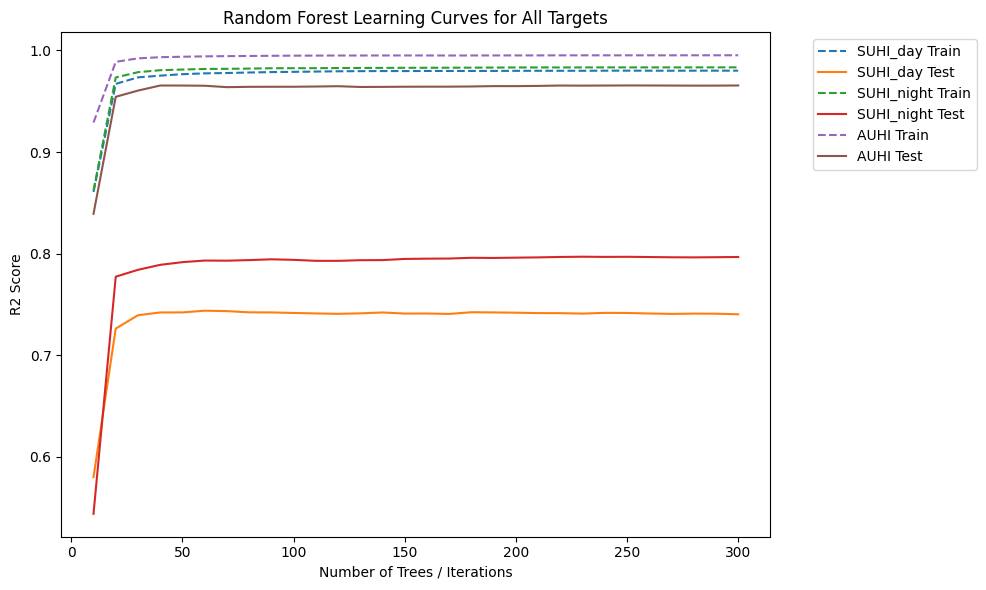

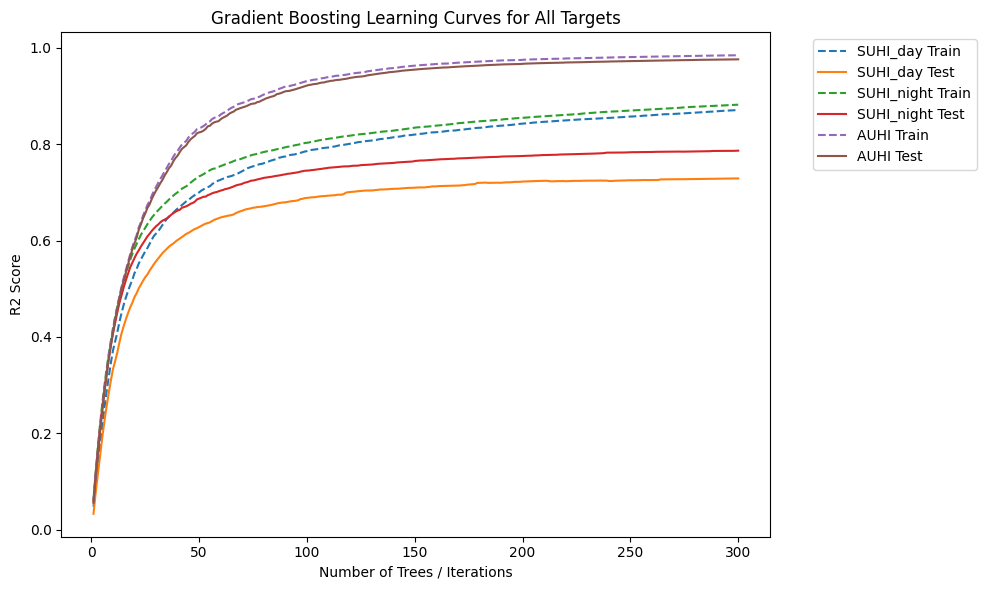

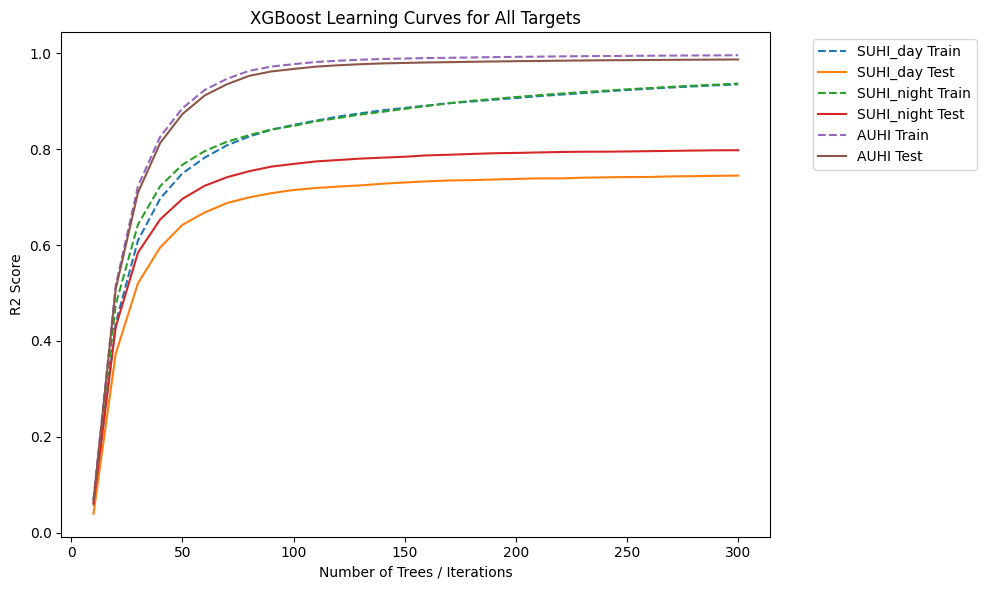

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from model_plots import plot_ensemble_learning_curves

# Call the function
plot_ensemble_learning_curves(tuned_models, X_train, y_train, X_test, y_test, targets, max_trees=300, step=10)

In [17]:
tuned_results = {}

for name, model in tuned_models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    model_results = {}

    for i, target in enumerate(targets):
        r2_train = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
        r2_test = r2_score(y_test.iloc[:, i], y_pred_test[:, i])
        mae_train = mean_absolute_error(y_train.iloc[:, i], y_pred_train[:, i])
        mae_test = mean_absolute_error(y_test.iloc[:, i], y_pred_test[:, i])
        rmse_test = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_test[:, i]))

        model_results[target] = {
            "R2_train": round(r2_train, 3),
            "R2_test": round(r2_test, 3),
            "R2_gap": round(r2_train - r2_test, 3),
            "MAE_train": round(mae_train, 3),
            "MAE_test": round(mae_test, 3),
            "MAE_gap": round(mae_test - mae_train, 3),
            "RMSE_test": round(rmse_test, 3)
        }

    tuned_results[name] = model_results


df_results = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results.items()
    for target, metrics in targets_dict.items()
])

display(df_results)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.980,0.740,0.240,0.471,1.660,1.189,2.793
1,Random Forest,SUHI_night,0.983,0.797,0.187,0.268,1.003,0.735,1.448
2,Random Forest,AUHI,0.995,0.966,0.030,0.168,0.430,0.262,0.861
3,Gradient Boosting,SUHI_day,0.871,0.729,0.142,1.330,1.832,0.502,2.851
4,Gradient Boosting,SUHI_night,0.882,0.787,0.095,0.747,1.081,0.334,1.484
5,Gradient Boosting,AUHI,0.985,0.976,0.008,0.392,0.466,0.074,0.713
6,XGBoost,SUHI_day,0.937,0.746,0.191,0.933,1.721,0.789,2.763
7,XGBoost,SUHI_night,0.938,0.798,0.141,0.540,1.035,0.496,1.445
8,XGBoost,AUHI,0.996,0.987,0.009,0.197,0.312,0.115,0.522
9,Linear Regression,SUHI_day,0.481,0.491,-0.011,2.779,2.865,0.086,3.907


### 3.4 Rebuilding Models with UFTVI as Outcome Variable

In [18]:
# New targets including UTFVI
targets_utfvi = ["SUHI_day", "SUHI_night", "AUHI", "UTFVI_day", "UTFVI_night"]

# Rebuild model_df with new targets
model_df_utfvi = uhi_data[features + targets_utfvi].copy()
model_df_utfvi["LandCover"] = model_df_utfvi["LandCover"].astype(int).astype(str)
model_df_utfvi = pd.get_dummies(model_df_utfvi, columns=["LandCover"], prefix="LC")
model_df_utfvi["month_sin"] = np.sin(2 * np.pi * model_df_utfvi["month"] / 12)
model_df_utfvi["month_cos"] = np.cos(2 * np.pi * model_df_utfvi["month"] / 12)
model_df_utfvi = model_df_utfvi.drop(columns=["month"])

# Add lat/lon for pixel-level split
model_df_utfvi["latitude"] = uhi_data["latitude"]
model_df_utfvi["longitude"] = uhi_data["longitude"]

# Pixel-level train/test split
feature_cols_utfvi = [c for c in model_df_utfvi.columns 
                      if c not in targets_utfvi + ["latitude", "longitude"]]

train_mask = model_df_utfvi[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

X_train_utfvi = model_df_utfvi[train_mask][feature_cols_utfvi]
X_test_utfvi = model_df_utfvi[~train_mask][feature_cols_utfvi]
y_train_utfvi = model_df_utfvi[train_mask][targets_utfvi]
y_test_utfvi = model_df_utfvi[~train_mask][targets_utfvi]


current_data_hash_utfvi = hash_data(X_train_utfvi, y_train_utfvi)

tuned_models_utfvi = {}
best_params_log_utfvi = {}

search_configs_utfvi = [
    ("Random Forest",
     MultiOutputRegressor(RandomForestRegressor(random_state=42)),
     rf_params),
    ("Gradient Boosting",
     MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
     gb_params),
    ("XGBoost",
     MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
     xgb_params)
]

for name, base_model, params in search_configs_utfvi:
    model_path, meta_path = get_paths(f"tuned_{name}_utfvi")
    current_param_hash = hash_dict(params)
    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if (
            meta.get("param_hash") == current_param_hash and
            meta.get("data_hash") == current_data_hash_utfvi
        ):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}_utfvi...")
        tuned_models_utfvi[name] = joblib.load(model_path)
    else:
        print(f"Tuning {name}_utfvi...")
        grid_search = GridSearchCV(
            base_model, params, cv=5, scoring="r2", n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train_utfvi, y_train_utfvi)
        model = grid_search.best_estimator_
        tuned_models_utfvi[name] = model
        best_params_log_utfvi[name] = grid_search.best_params_
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({
                "param_hash": current_param_hash,
                "data_hash": current_data_hash_utfvi
            }, f, indent=4)
        print(f"Saved {name}_utfvi")

# Linear models
linear_models_utfvi = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0))
}

for name, model in linear_models_utfvi.items():
    model_path, meta_path = get_paths(f"{name}_utfvi")
    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if meta.get("data_hash") == current_data_hash_utfvi:
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}_utfvi...")
        tuned_models_utfvi[name] = joblib.load(model_path)
    else:
        print(f"Training {name}_utfvi...")
        model.fit(X_train_utfvi, y_train_utfvi)
        tuned_models_utfvi[name] = model
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash_utfvi}, f, indent=4)
        print(f"Saved {name}_utfvi")

Loading cached Random Forest_utfvi...
Loading cached Gradient Boosting_utfvi...
Loading cached XGBoost_utfvi...
Loading cached Linear Regression_utfvi...
Loading cached Ridge Regression_utfvi...


#### 3.4.1 Visualizing Performances on UFTVI Models

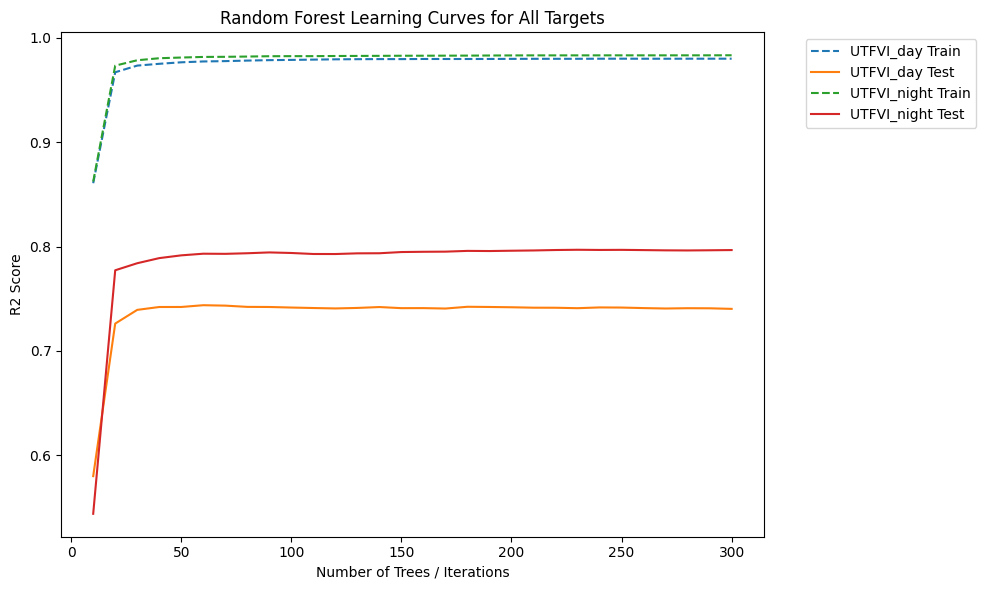

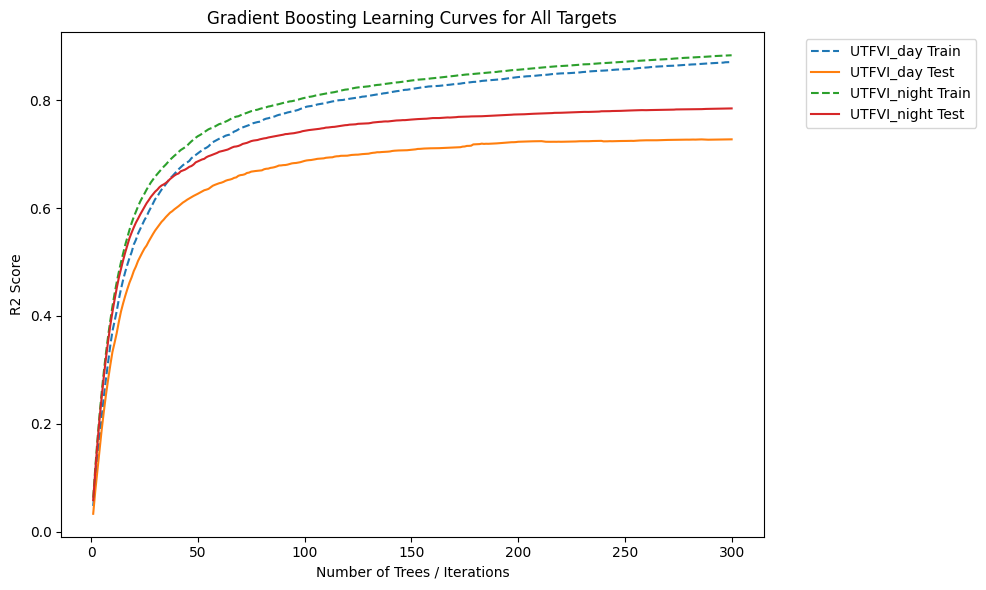

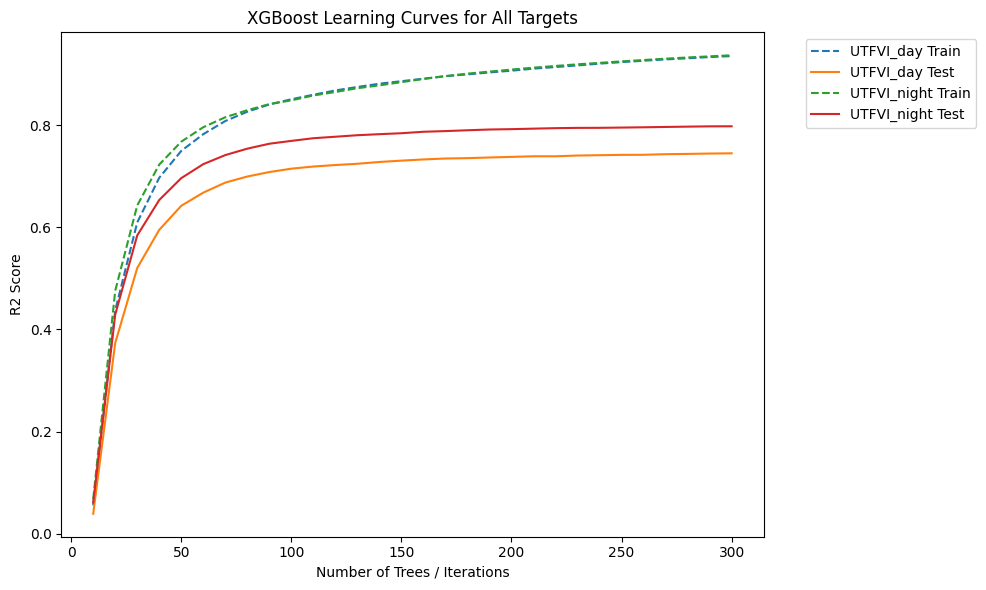

In [19]:
plot_ensemble_learning_curves(tuned_models_utfvi, X_train_utfvi, y_train_utfvi, X_test_utfvi, y_test_utfvi, ["UTFVI_day", "UTFVI_night"], max_trees=300, step=10)

In [20]:
tuned_results_utfvi = {}

for name, model in tuned_models_utfvi.items():
    y_pred_train_utfvi = model.predict(X_train_utfvi)
    y_pred_test_utfvi = model.predict(X_test_utfvi)

    model_results_utfvi = {}

    for i, target in enumerate(targets_utfvi):
        r2_train_utfvi = r2_score(y_train_utfvi.iloc[:, i], y_pred_train_utfvi[:, i])
        r2_test_utfvi = r2_score(y_test_utfvi.iloc[:, i], y_pred_test_utfvi[:, i])
        mae_train_utfvi = mean_absolute_error(y_train_utfvi.iloc[:, i], y_pred_train_utfvi[:, i])
        mae_test_utfvi = mean_absolute_error(y_test_utfvi.iloc[:, i], y_pred_test_utfvi[:, i])
        rmse_test_utfvi = np.sqrt(mean_squared_error(y_test_utfvi.iloc[:, i], y_pred_test_utfvi[:, i]))

        model_results_utfvi[target] = {
            "R2_train": round(r2_train_utfvi, 3),
            "R2_test": round(r2_test_utfvi, 3),
            "R2_gap": round(r2_train_utfvi - r2_test_utfvi, 3),
            "MAE_train": round(mae_train_utfvi, 3),
            "MAE_test": round(mae_test_utfvi, 3),
            "MAE_gap": round(mae_test_utfvi - mae_train_utfvi, 3),
            "RMSE_test": round(rmse_test_utfvi, 3)
        }

    tuned_results_utfvi[name] = model_results_utfvi


df_results_utfvi = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results_utfvi.items()
    for target, metrics in targets_dict.items()
])

display(df_results_utfvi)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.980,0.740,0.240,0.471,1.660,1.189,2.793
1,Random Forest,SUHI_night,0.983,0.797,0.187,0.268,1.003,0.735,1.448
2,Random Forest,AUHI,0.995,0.966,0.030,0.168,0.430,0.262,0.861
3,Random Forest,UTFVI_day,0.978,0.716,0.261,0.002,0.006,0.004,0.009
4,Random Forest,UTFVI_night,0.983,0.781,0.202,0.001,0.003,0.003,0.005
5,Gradient Boosting,SUHI_day,0.871,0.728,0.143,1.335,1.828,0.494,2.859
6,Gradient Boosting,SUHI_night,0.884,0.785,0.099,0.744,1.085,0.341,1.490
7,Gradient Boosting,AUHI,0.985,0.976,0.009,0.393,0.474,0.080,0.716
8,Gradient Boosting,UTFVI_day,0.854,0.709,0.145,0.004,0.006,0.002,0.009
9,Gradient Boosting,UTFVI_night,0.877,0.769,0.108,0.003,0.004,0.001,0.005


### 3.5 Rebuilding Models Without Elevation and Coordinates

In [21]:
features_no_geo = ["humidity", "precipitation", "wind_speed", "cloud_cover_low",
                   "air_temperature", "Albedo", "MNDWI", "NDBI", "SAVI", "LandCover", "month"]

targets_utfvi = ["SUHI_day", "SUHI_night", "AUHI", "UTFVI_day", "UTFVI_night"]

model_df_nogeo = uhi_data[features_no_geo + targets_utfvi].copy()
model_df_nogeo["LandCover"] = model_df_nogeo["LandCover"].astype(int).astype(str)
model_df_nogeo = pd.get_dummies(model_df_nogeo, columns=["LandCover"], prefix="LC")
model_df_nogeo["month_sin"] = np.sin(2 * np.pi * model_df_nogeo["month"] / 12)
model_df_nogeo["month_cos"] = np.cos(2 * np.pi * model_df_nogeo["month"] / 12)
model_df_nogeo = model_df_nogeo.drop(columns=["month"])

model_df_nogeo["latitude"] = uhi_data["latitude"]
model_df_nogeo["longitude"] = uhi_data["longitude"]

feature_cols_nogeo = [c for c in model_df_nogeo.columns 
                      if c not in targets_utfvi + ["latitude", "longitude"]]

train_mask = model_df_nogeo[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

X_train_nogeo = model_df_nogeo[train_mask][feature_cols_nogeo]
X_test_nogeo = model_df_nogeo[~train_mask][feature_cols_nogeo]
y_train_nogeo = model_df_nogeo[train_mask][targets_utfvi]
y_test_nogeo = model_df_nogeo[~train_mask][targets_utfvi]

print(f"X_train: {X_train_nogeo.shape}, X_test: {X_test_nogeo.shape}")

X_train: (15192, 21), X_test: (3816, 21)


In [22]:
current_data_hash_nogeo = hash_data(X_train_nogeo, y_train_nogeo)
tuned_models_nogeo = {}

search_configs_nogeo = [
    ("Random Forest", MultiOutputRegressor(RandomForestRegressor(random_state=42)), rf_params),
    ("Gradient Boosting", MultiOutputRegressor(GradientBoostingRegressor(random_state=42)), gb_params),
    ("XGBoost", MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)), xgb_params)
]

for name, base_model, params in search_configs_nogeo:
    model_path, meta_path = get_paths(f"tuned_{name}_nogeo")
    current_param_hash = hash_dict(params)
    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if (meta.get("param_hash") == current_param_hash and
                meta.get("data_hash") == current_data_hash_nogeo):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}_nogeo...")
        tuned_models_nogeo[name] = joblib.load(model_path)
    else:
        print(f"Tuning {name}_nogeo...")
        grid_search = GridSearchCV(
            base_model, params, cv=5, scoring="r2", n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train_nogeo, y_train_nogeo)
        model = grid_search.best_estimator_
        tuned_models_nogeo[name] = model
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({
                "param_hash": current_param_hash,
                "data_hash": current_data_hash_nogeo
            }, f, indent=4)
        print(f"Saved {name}_nogeo")

for name, model in [
    ("Linear Regression", MultiOutputRegressor(LinearRegression())),
    ("Ridge Regression", MultiOutputRegressor(Ridge(alpha=1.0)))
]:
    model_path, meta_path = get_paths(f"{name}_nogeo")
    use_cache = False
    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if meta.get("data_hash") == current_data_hash_nogeo:
            use_cache = True
    if use_cache:
        print(f"Loading cached {name}_nogeo...")
        tuned_models_nogeo[name] = joblib.load(model_path)
    else:
        print(f"Training {name}_nogeo...")
        model.fit(X_train_nogeo, y_train_nogeo)
        tuned_models_nogeo[name] = model
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash_nogeo}, f, indent=4)

Loading cached Random Forest_nogeo...
Loading cached Gradient Boosting_nogeo...
Loading cached XGBoost_nogeo...
Loading cached Linear Regression_nogeo...
Loading cached Ridge Regression_nogeo...


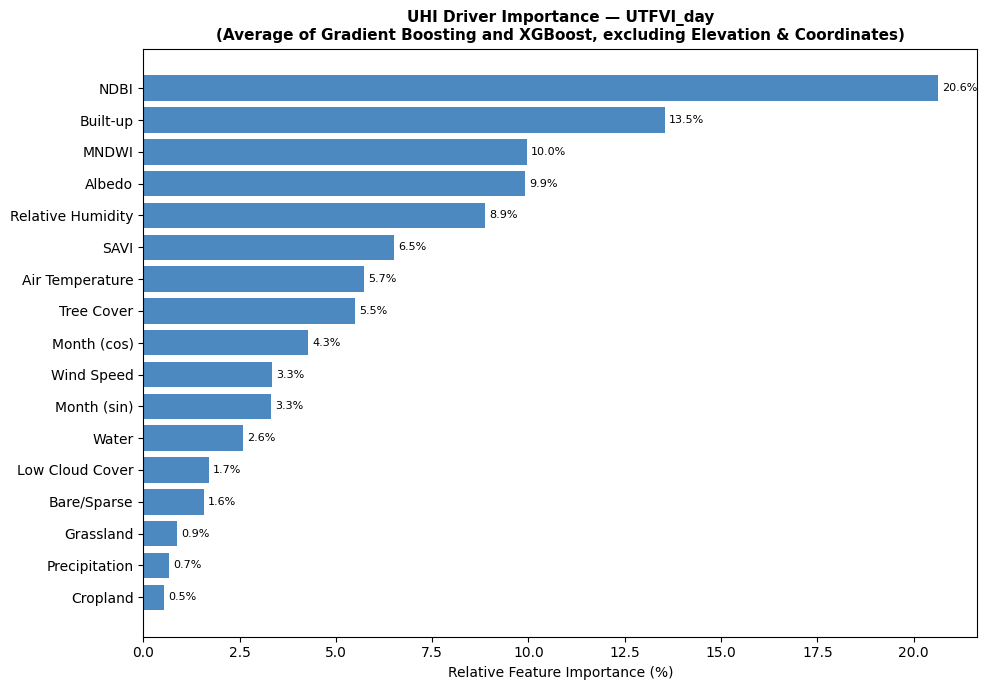

Saved overall UTFVI_day


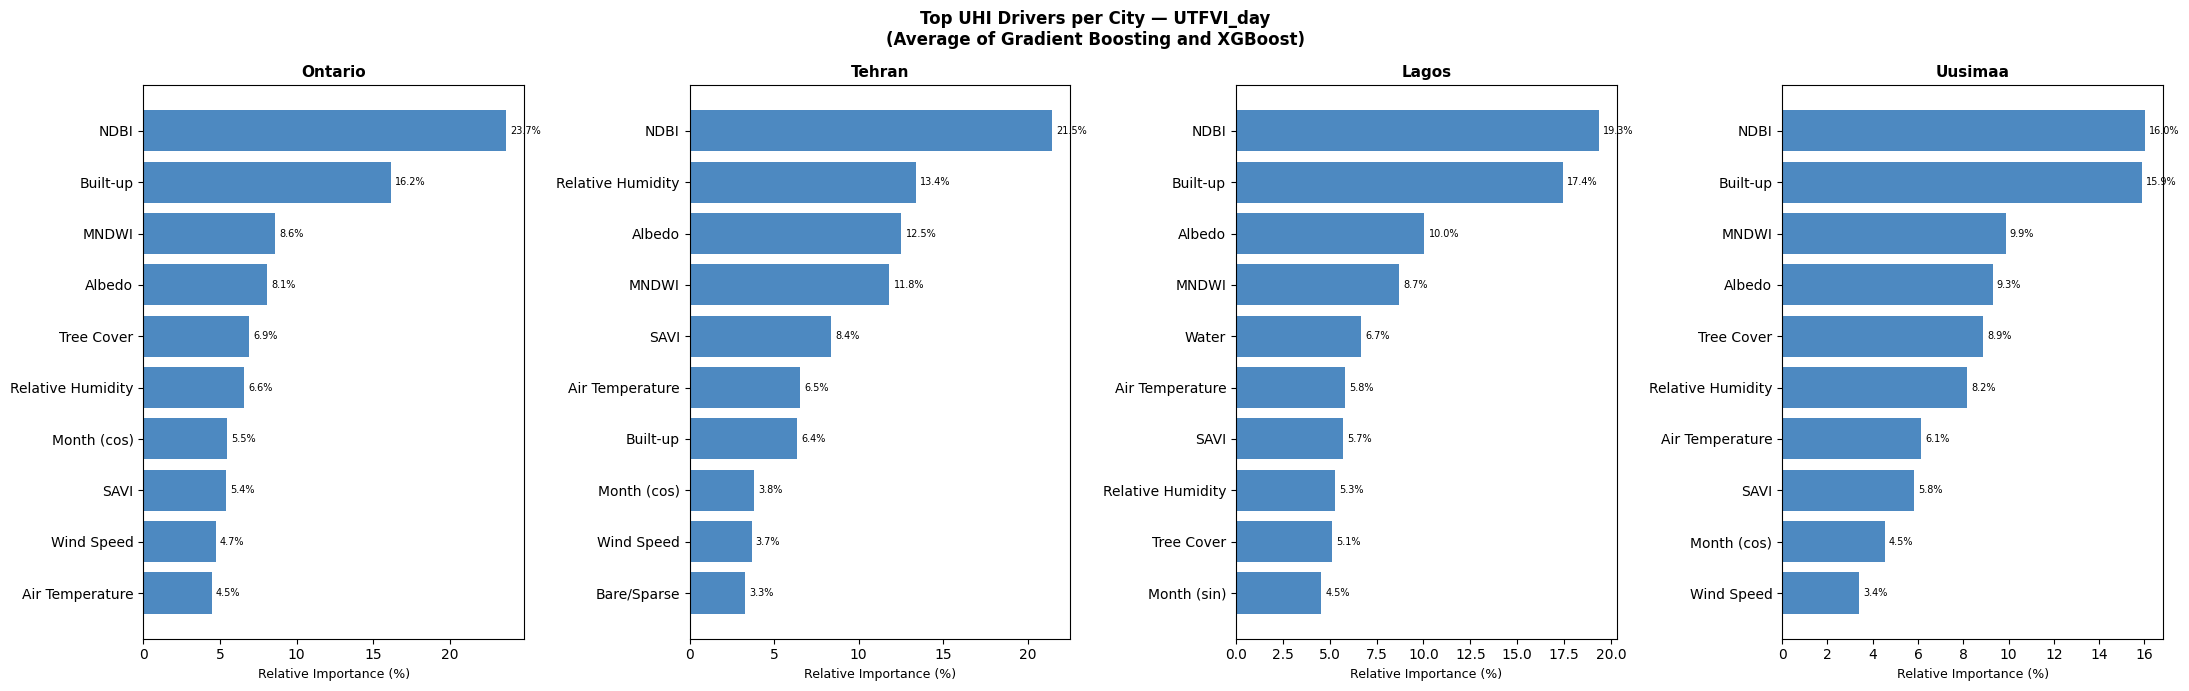

Saved per-city UTFVI_day

--- UTFVI_day Relative Importance Table ---
NDBI                 20.62
Built-up             13.54
MNDWI                 9.95
Albedo                9.90
Relative Humidity     8.88
SAVI                  6.50
Air Temperature       5.73
Tree Cover            5.51
Month (cos)           4.29
Wind Speed            3.33
Month (sin)           3.32
Water                 2.60
Low Cloud Cover       1.70
Bare/Sparse           1.56
Grassland             0.88
Precipitation         0.67
Cropland              0.53


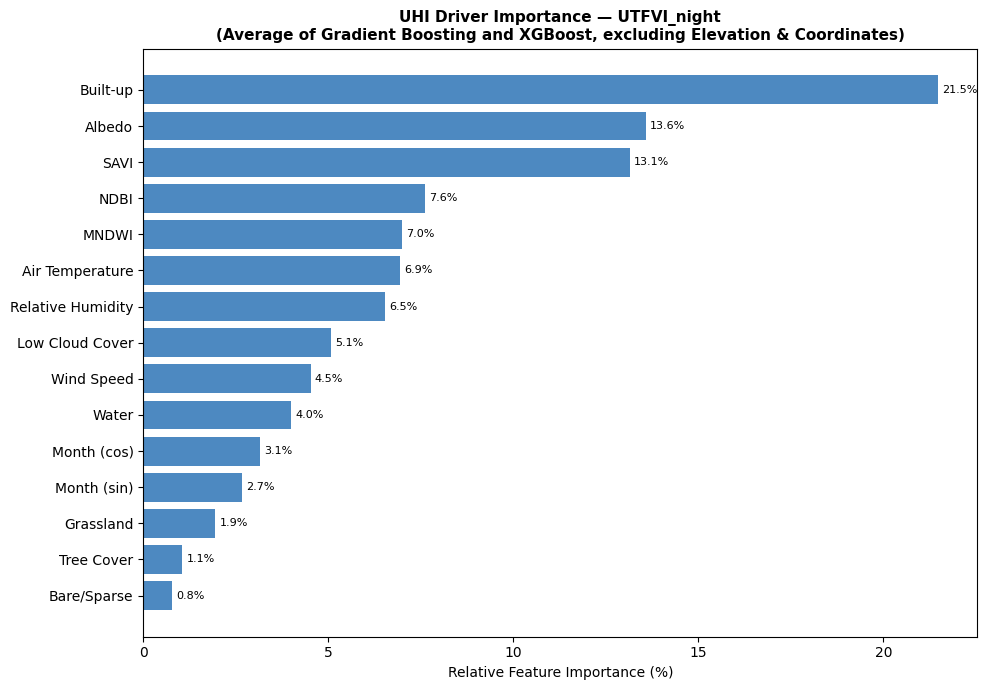

Saved overall UTFVI_night


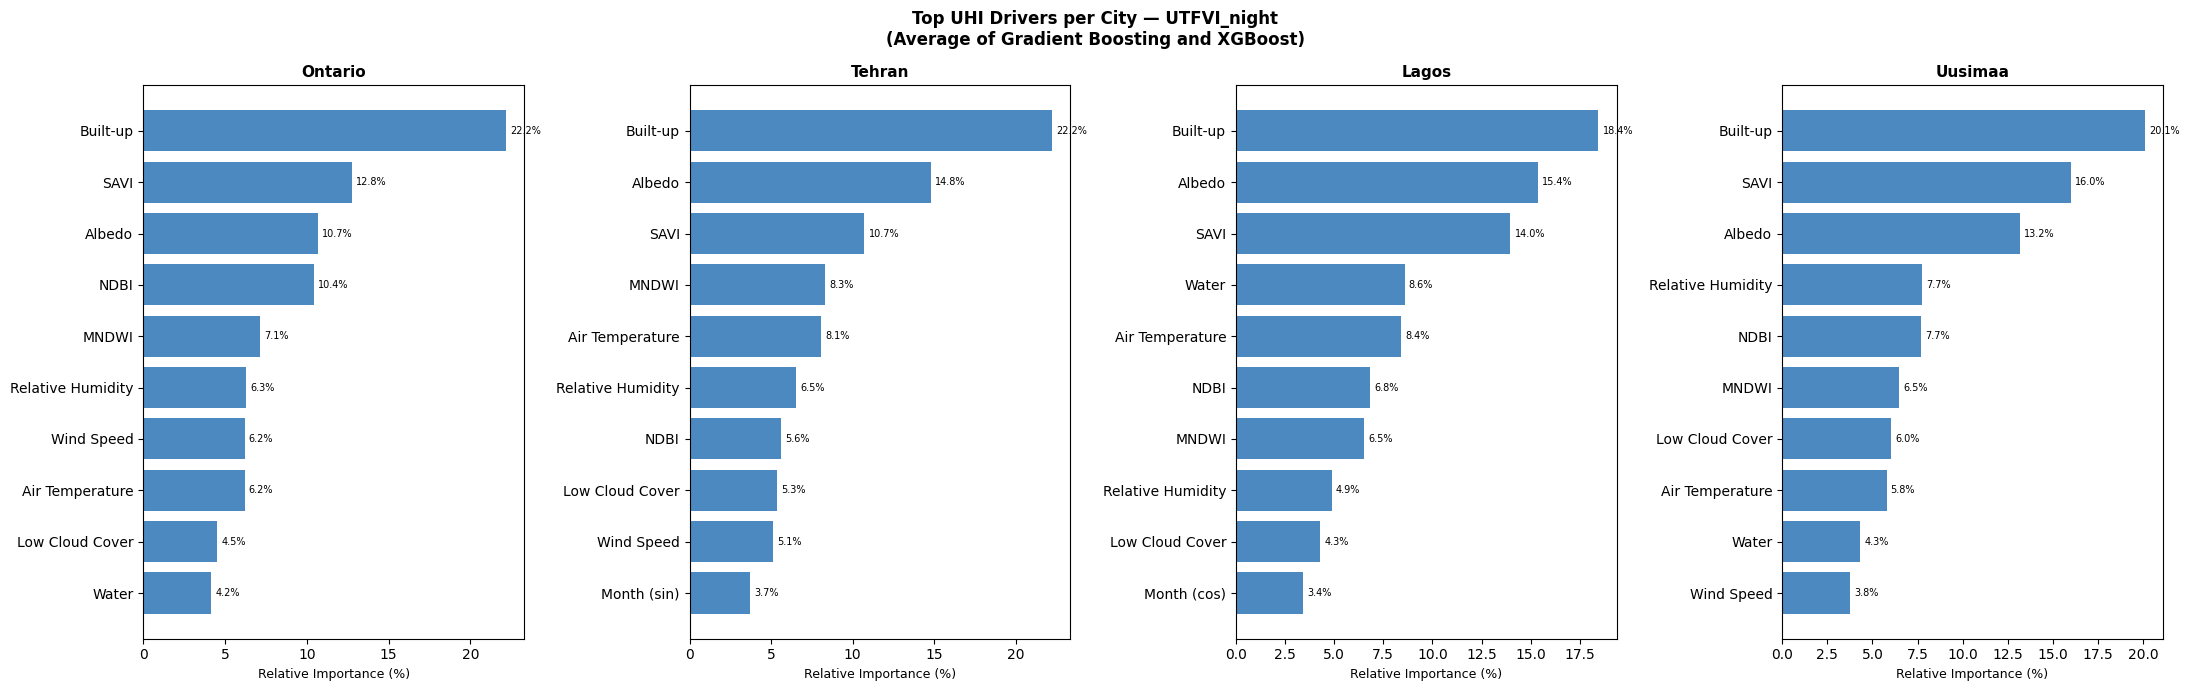

Saved per-city UTFVI_night

--- UTFVI_night Relative Importance Table ---
Built-up             21.47
Albedo               13.58
SAVI                 13.15
NDBI                  7.62
MNDWI                 7.00
Air Temperature       6.95
Relative Humidity     6.53
Low Cloud Cover       5.07
Wind Speed            4.52
Water                 3.99
Month (cos)           3.15
Month (sin)           2.66
Grassland             1.94
Tree Cover            1.06
Bare/Sparse           0.78


In [23]:
import shap
import pandas as pd

os.makedirs("plots/shap/utfvi", exist_ok=True)

utfvi_targets = ["UTFVI_day", "UTFVI_night"]
utfvi_indices = [targets_utfvi.index(t) for t in utfvi_targets]
model_names = ["Gradient Boosting", "XGBoost"]

feature_display_names = {
    "humidity": "Relative Humidity",
    "precipitation": "Precipitation",
    "wind_speed": "Wind Speed",
    "cloud_cover_low": "Low Cloud Cover",
    "air_temperature": "Air Temperature",
    "Albedo": "Albedo",
    "MNDWI": "MNDWI",
    "NDBI": "NDBI",
    "SAVI": "SAVI",
    "month_sin": "Month (sin)",
    "month_cos": "Month (cos)",
    "LC_10": "Tree Cover",
    "LC_20": "Shrubland",
    "LC_30": "Grassland",
    "LC_40": "Cropland",
    "LC_50": "Built-up",
    "LC_60": "Bare/Sparse",
    "LC_80": "Water",
    "LC_90": "Wetland",
    "LC_95": "Mangroves",
    "LC_100": "Moss/Lichen"
}

cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]

for target, idx in zip(utfvi_targets, utfvi_indices):
    # Collect SHAP across both models
    all_shap = []
    
    for model_name in model_names:
        model = tuned_models_nogeo[model_name]
        estimator = model.estimators_[idx]
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_nogeo)
        all_shap.append(shap_values)
    
    mean_shap = np.mean(all_shap, axis=0)
    mean_abs_shap = np.abs(mean_shap).mean(axis=0)
    
    # Normalise to percentage of total importance
    mean_abs_shap_pct = mean_abs_shap / mean_abs_shap.sum() * 100
    
    shap_series = pd.Series(mean_abs_shap_pct, index=feature_cols_nogeo)
    shap_series.index = [feature_display_names.get(f, f) for f in shap_series.index]
    
    # Drop near-zero features (< 0.5% importance)
    shap_series = shap_series[shap_series > 0.5].sort_values(ascending=True)
    
    # --- Overall plot ---
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(shap_series.index, shap_series.values, color="#2E75B6", alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlabel("Relative Feature Importance (%)", fontsize=10)
    ax.set_title(f"UHI Driver Importance — {target}\n(Average of Gradient Boosting and XGBoost, excluding Elevation & Coordinates)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"plots/shap/utfvi/{target}_overall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved overall {target}")

    # --- Per city plot ---
    fig, axes = plt.subplots(1, 4, figsize=(22, 7), sharey=False)
    
    for ax, city in zip(axes, cities):
        city_mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
        
        city_shap_list = []
        for model_name in model_names:
            model = tuned_models_nogeo[model_name]
            estimator = model.estimators_[idx]
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(X_test_nogeo)
            city_shap = np.abs(shap_values[city_mask]).mean(axis=0)
            city_shap_list.append(city_shap)
        
        mean_city_shap = np.mean(city_shap_list, axis=0)
        mean_city_shap_pct = mean_city_shap / mean_city_shap.sum() * 100
        
        city_series = pd.Series(mean_city_shap_pct, index=feature_cols_nogeo)
        city_series.index = [feature_display_names.get(f, f) for f in city_series.index]
        city_series = city_series[city_series > 0.5].sort_values(ascending=True).tail(10)
        
        bars = ax.barh(city_series.index, city_series.values, color="#2E75B6", alpha=0.85)
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=7)
        ax.set_title(city, fontsize=11, fontweight="bold")
        ax.set_xlabel("Relative Importance (%)", fontsize=9)
    
    fig.suptitle(f"Top UHI Drivers per City — {target}\n(Average of Gradient Boosting and XGBoost)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"plots/shap/utfvi/{target}_per_city.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved per-city {target}")

    # Print table
    print(f"\n--- {target} Relative Importance Table ---")
    print(shap_series.sort_values(ascending=False).round(2).to_string())

## 4. Results

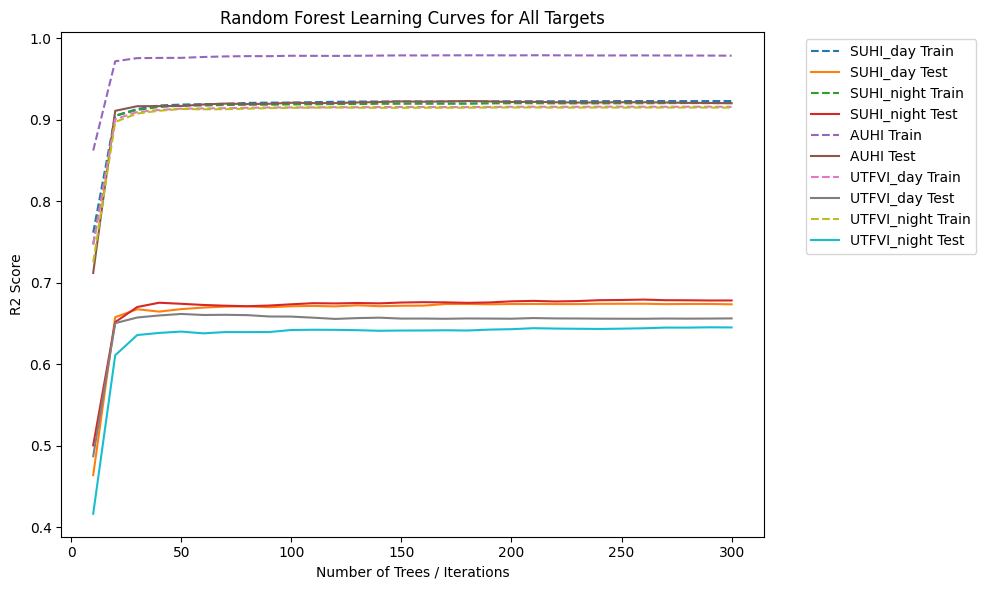

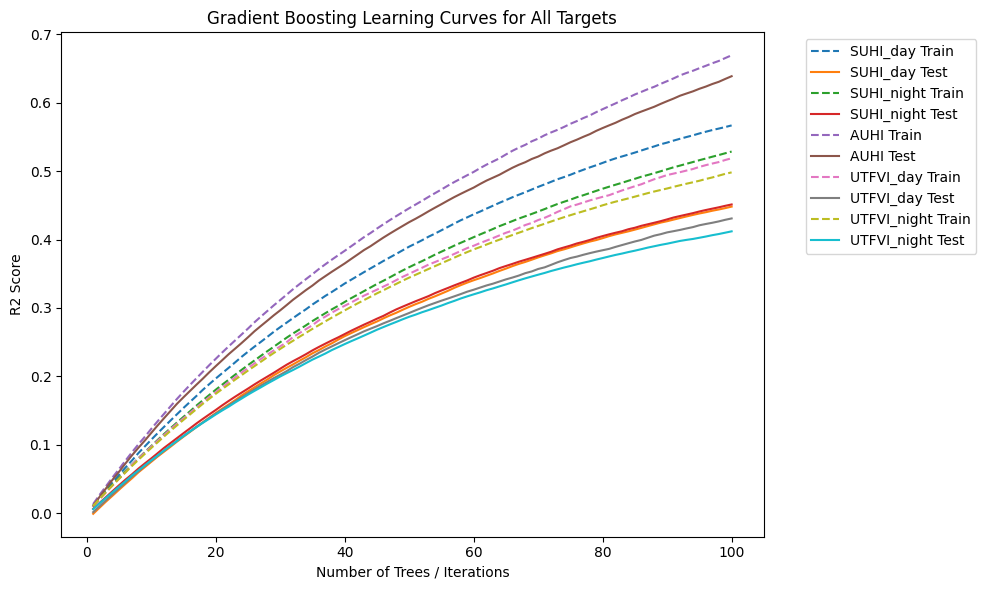

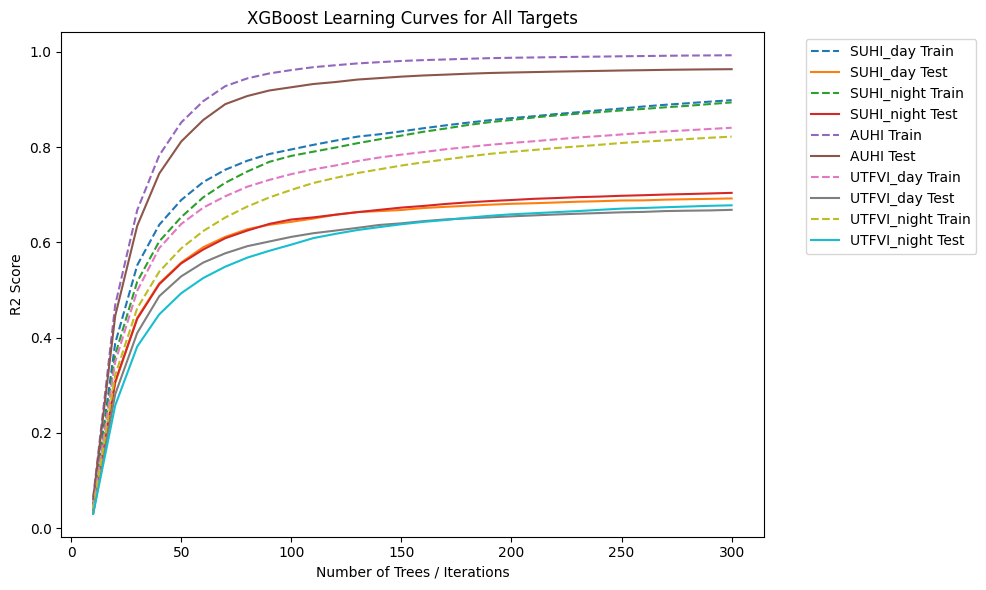

In [24]:
plot_ensemble_learning_curves(tuned_models_nogeo, X_train_nogeo, y_train_nogeo, X_test_nogeo, y_test_nogeo, targets_utfvi, max_trees=300, step=10)

In [25]:
tuned_results_nogeo = {}
for name, model in tuned_models_nogeo.items():
    y_pred_train_nogeo = model.predict(X_train_nogeo)
    y_pred_test_nogeo = model.predict(X_test_nogeo)
    model_results_nogeo = {}  
    for i, target in enumerate(targets_utfvi):
        r2_train = r2_score(y_train_nogeo.iloc[:, i], y_pred_train_nogeo[:, i])
        r2_test = r2_score(y_test_nogeo.iloc[:, i], y_pred_test_nogeo[:, i])
        mae_train = mean_absolute_error(y_train_nogeo.iloc[:, i], y_pred_train_nogeo[:, i])
        mae_test = mean_absolute_error(y_test_nogeo.iloc[:, i], y_pred_test_nogeo[:, i])
        rmse_test = np.sqrt(mean_squared_error(y_test_nogeo.iloc[:, i], y_pred_test_nogeo[:, i]))
        model_results_nogeo[target] = {  # fixed
            "R2_train": round(r2_train, 3),
            "R2_test": round(r2_test, 3),
            "R2_gap": round(r2_train - r2_test, 3),
            "MAE_train": round(mae_train, 3),
            "MAE_test": round(mae_test, 3),
            "MAE_gap": round(mae_test - mae_train, 3),
            "RMSE_test": round(rmse_test, 3)
        }
    tuned_results_nogeo[name] = model_results_nogeo  # fixed

df_results_nogeo = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results_nogeo.items()
    for target, metrics in targets_dict.items()
])
display(df_results_nogeo)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.923,0.674,0.249,0.920,1.841,0.921,3.127
1,Random Forest,SUHI_night,0.920,0.678,0.242,0.545,1.126,0.582,1.823
2,Random Forest,AUHI,0.979,0.922,0.057,0.330,0.592,0.262,1.293
3,Random Forest,UTFVI_day,0.916,0.657,0.259,0.003,0.006,0.003,0.010
4,Random Forest,UTFVI_night,0.915,0.644,0.271,0.002,0.004,0.002,0.006
5,Gradient Boosting,SUHI_day,0.567,0.448,0.119,2.464,2.671,0.207,4.069
6,Gradient Boosting,SUHI_night,0.529,0.451,0.077,1.466,1.666,0.200,2.380
7,Gradient Boosting,AUHI,0.670,0.639,0.031,1.890,1.976,0.086,2.785
8,Gradient Boosting,UTFVI_day,0.519,0.431,0.088,0.008,0.009,0.001,0.013
9,Gradient Boosting,UTFVI_night,0.498,0.412,0.086,0.005,0.005,0.001,0.008


In [26]:
# Global relative importance table
print(shap_series.sort_values(ascending=False).round(3).to_string())

# Per city relative importance for UTFVI_day
for city in ["Ontario", "Tehran", "Lagos", "Uusimaa"]:
    city_mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
    city_shap_list = []
    for model_name in ["XGBoost"]:
        model = tuned_models_nogeo[model_name]
        estimator = model.estimators_[targets_utfvi.index("UTFVI_day")]
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_nogeo)
        city_shap = np.abs(shap_values[city_mask]).mean(axis=0)
        city_shap_pct = city_shap / city_shap.sum() * 100
        city_series = pd.Series(city_shap_pct, index=feature_cols_nogeo)
        city_series.index = [feature_display_names.get(f, f) for f in city_series.index]
        city_series = city_series[city_series > 0.5].sort_values(ascending=False)
    print(f"\n{city}:")
    print(city_series.round(1).to_string())

Built-up             21.469
Albedo               13.579
SAVI                 13.147
NDBI                  7.623
MNDWI                 7.000
Air Temperature       6.945
Relative Humidity     6.528
Low Cloud Cover       5.070
Wind Speed            4.524
Water                 3.988
Month (cos)           3.150
Month (sin)           2.658
Grassland             1.945
Tree Cover            1.060
Bare/Sparse           0.778

Ontario:
NDBI                 21.4
Built-up             14.7
MNDWI                10.7
Albedo                8.8
Relative Humidity     7.6
SAVI                  6.5
Month (cos)           6.2
Air Temperature       5.2
Wind Speed            4.9
Tree Cover            4.5
Month (sin)           3.2
Low Cloud Cover       2.1
Precipitation         1.2
Water                 1.2
Bare/Sparse           0.6
Grassland             0.6

Tehran:
NDBI                 18.4
Relative Humidity    14.5
MNDWI                14.3
Albedo               11.0
SAVI                  9.2
Air Temperature

## 5. Making Polished Plots

### 5.1 Universal Heatmap

C:\Users\djmck\AppData\Local\Temp\ipykernel_20924\3569200373.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_df, x='Importance', y='Group', ax=ax, palette="rocket")
C:\Users\djmck\AppData\Local\Temp\ipykernel_20924\3569200373.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_df, x='Importance', y='Group', ax=ax, palette="rocket")
C:\Users\djmck\AppData\Local\Temp\ipykernel_20924\3569200373.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_df, x='Importance', y='Group', ax=ax, palette="rocket"

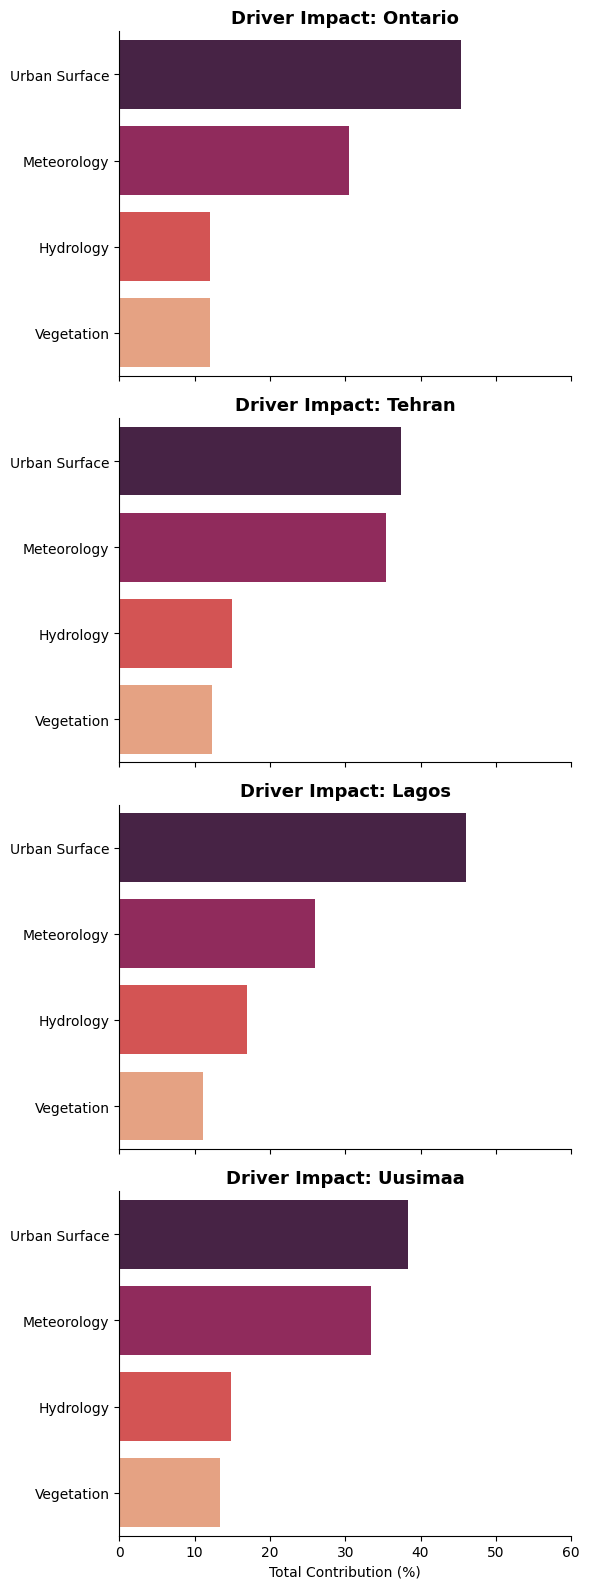

In [27]:
import seaborn as sns

groups = {
    "Urban Surface": ["Built-up", "NDBI", "Albedo", "Bare/Sparse"],
    "Vegetation": ["SAVI", "Tree Cover", "Grassland", "Shrubland", "Cropland"],
    "Meteorology": ["Air Temperature", "Relative Humidity", "Wind Speed", 
                    "Low Cloud Cover", "Precipitation", "Month (sin)", "Month (cos)"],
    "Hydrology": ["MNDWI", "Water", "Wetland", "Mangroves", "Moss/Lichen"]
}

# Aggregate city_series based on these groups
grouped_data = {label: city_series[city_series.index.isin(features)].sum() 
                for label, features in groups.items()}

# Create a reverse mapping for easy lookup: {Feature: Group}
feature_to_group = {}
for group_name, feature_list in groups.items():
    for feature_name in feature_list:
        feature_to_group[feature_name] = group_name

fig, axes = plt.subplots(4, 1, figsize=(6, 16), sharex=True)

for i, city in enumerate(["Ontario", "Tehran", "Lagos", "Uusimaa"]):
    # --- SHAP Logic ---
    city_mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
    estimator = tuned_models_nogeo["XGBoost"].estimators_[targets_utfvi.index("UTFVI_day")]
    explainer = shap.TreeExplainer(estimator)
    
    shap_values = explainer.shap_values(X_test_nogeo[city_mask])
    city_shap = np.abs(shap_values).mean(axis=0)
    city_shap_pct = (city_shap / city_shap.sum() * 100)
    
    # --- Data Preparation with Grouping ---
    temp_df = pd.DataFrame({
        'Feature': [feature_display_names.get(f, f) for f in feature_cols_nogeo],
        'Importance': city_shap_pct
    })
    
    # Map features to groups and aggregate
    temp_df['Group'] = temp_df['Feature'].map(feature_to_group).fillna("Other")
    grouped_df = temp_df.groupby('Group')['Importance'].sum().reset_index()
    grouped_df = grouped_df.sort_values('Importance', ascending=False)

    # --- Plotting ---
    ax = axes[i]
    # Use a fixed color palette for groups so they stay consistent across cities
    sns.barplot(data=grouped_df, x='Importance', y='Group', ax=ax, palette="rocket")
    
    ax.set_title(f"Driver Impact: {city}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Contribution (%)" if i == 3 else "")
    ax.set_ylabel("")
    ax.set_xlim(0, 60) # Standardize x-axis to see relative dominance
    sns.despine()

plt.tight_layout()
plt.show()

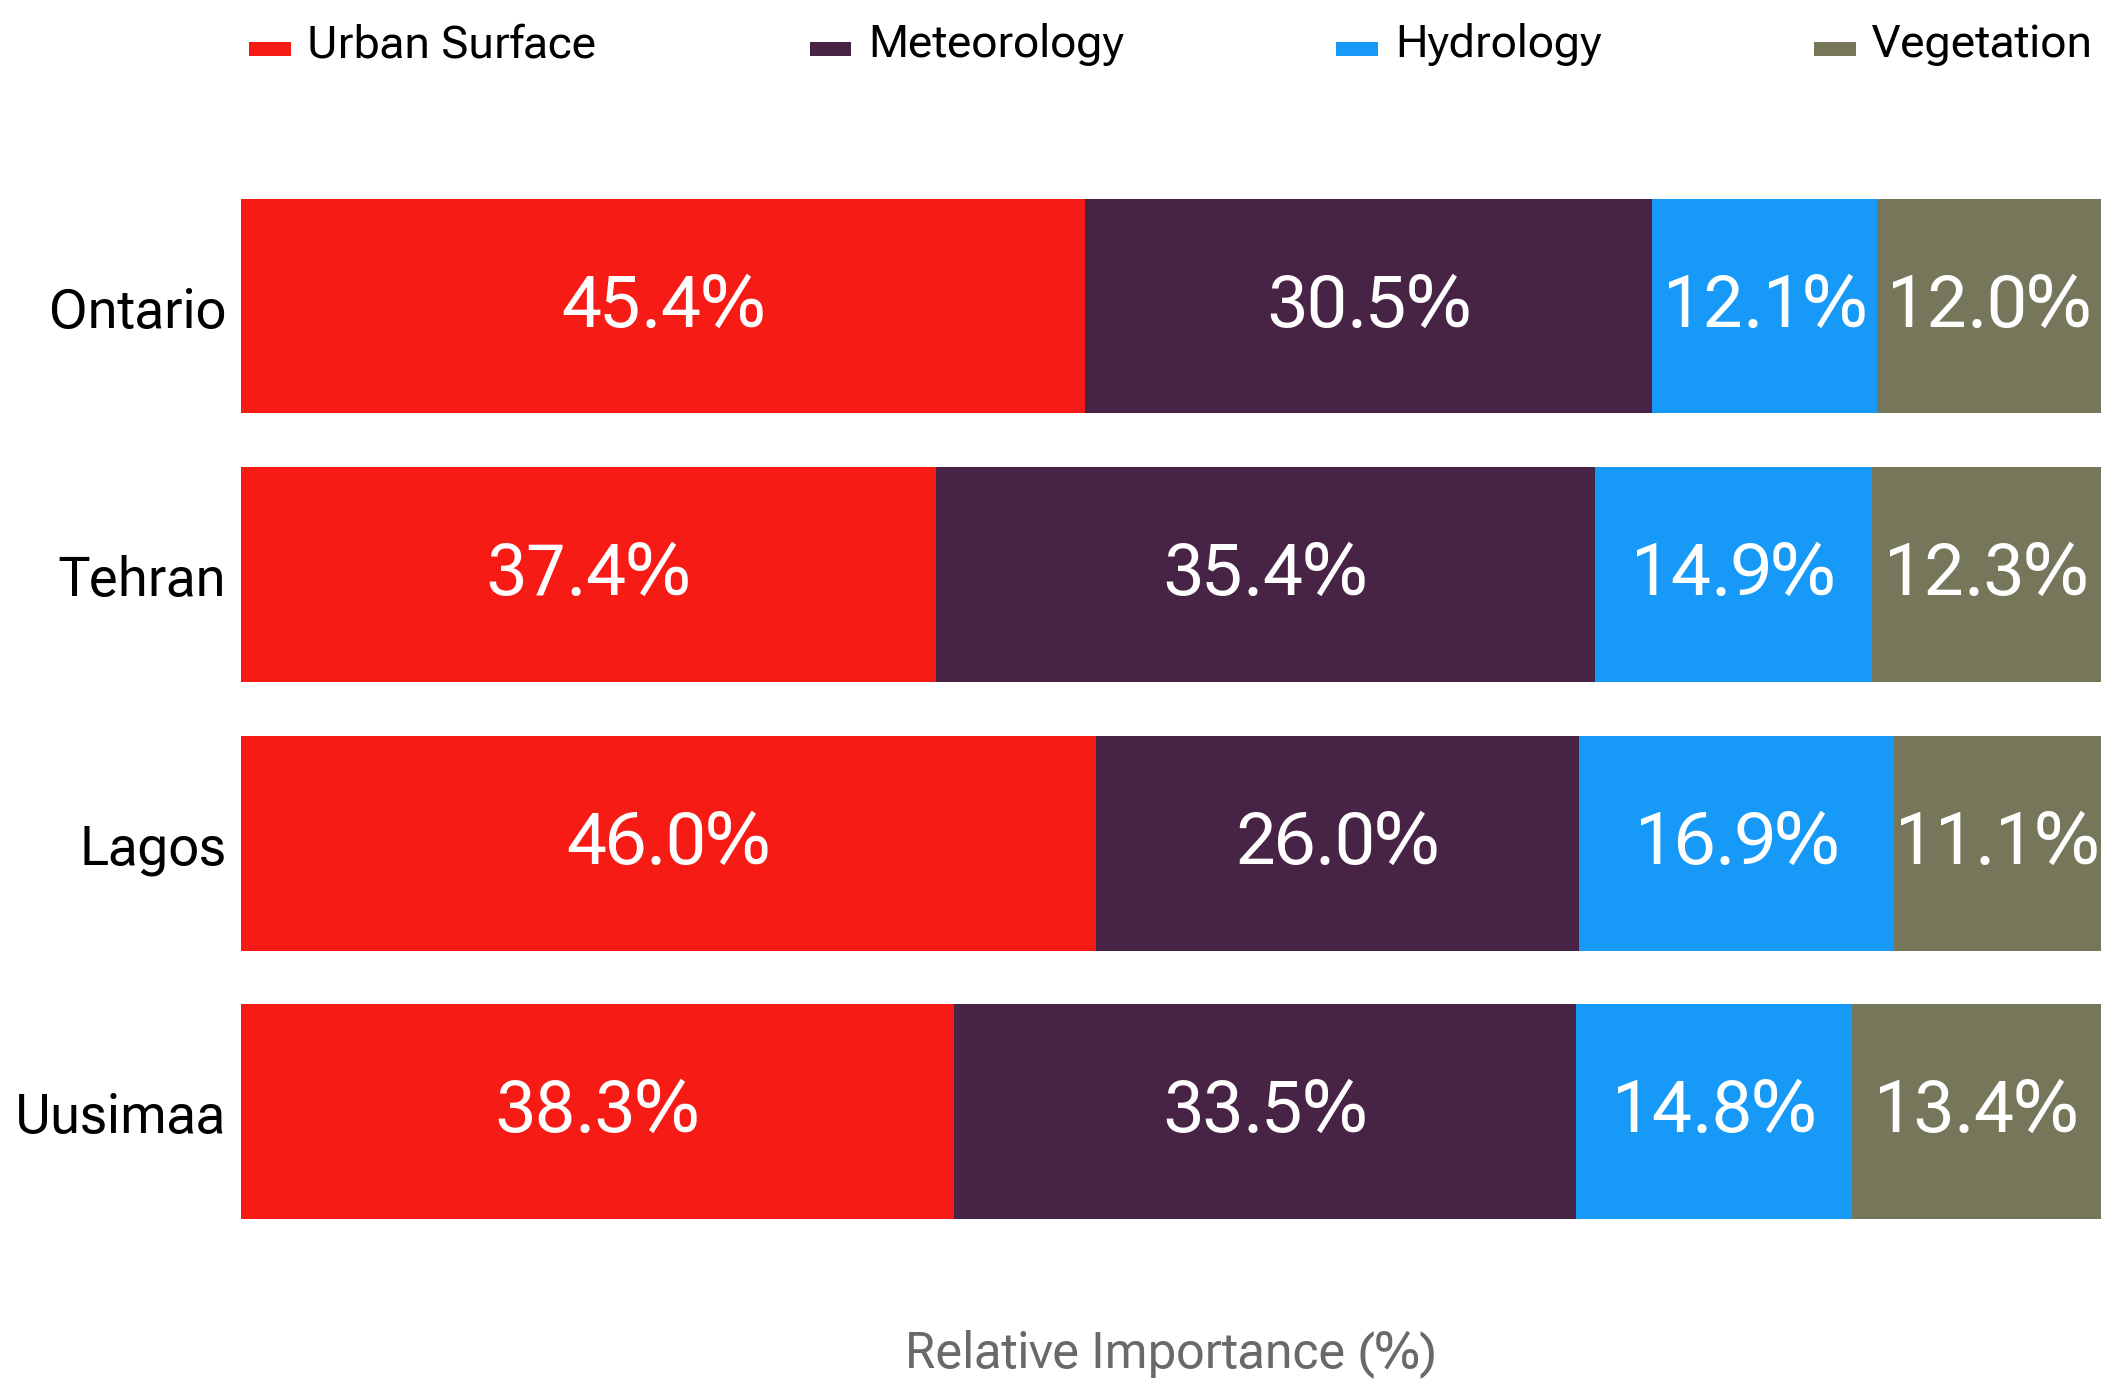

In [28]:
import matplotlib.ticker as ticker
from pyfonts import load_google_font
import os

# --- 1. Setup Groups & Fonts ---
groups = {
    "Urban Surface": ["Built-up", "NDBI", "Albedo", "Bare/Sparse"],
    "Vegetation": ["SAVI", "Tree Cover", "Grassland", "Shrubland", "Cropland"],
    "Meteorology": ["Air Temperature", "Relative Humidity", "Wind Speed", 
                    "Low Cloud Cover", "Precipitation", "Month (sin)", "Month (cos)"],
    "Hydrology": ["MNDWI", "Water", "Wetland", "Mangroves", "Moss/Lichen"]
}

# Mapping and Colors
feature_to_group = {feat: g for g, feats in groups.items() for feat in feats}
color_map = {
    "Urban Surface": "#F71B16", 
    "Meteorology": "#472345", 
    "Hydrology": "#1699F7", 
    "Vegetation": "#76765B"
}

# Font Setup (Ensure the path to your Roboto Flex file is correct)
# If it's already installed on your system, you can often just use "Roboto Flex"
roboto_font = load_google_font("Roboto Flex")

# --- 2. Aggregate Data Across Cities ---
cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]
all_city_results = []

for city in cities:
    # SHAP Logic
    city_mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
    estimator = tuned_models_nogeo["XGBoost"].estimators_[targets_utfvi.index("UTFVI_day")]
    explainer = shap.TreeExplainer(estimator)
    
    # Calculate Mean Absolute SHAP ($|SHAP|$)
    shap_values = explainer.shap_values(X_test_nogeo[city_mask])
    city_shap = np.abs(shap_values).mean(axis=0)
    city_shap_pct = (city_shap / city_shap.sum() * 100)
    
    # Map to groups
    temp_df = pd.DataFrame({
        'Feature': [feature_display_names.get(f, f) for f in feature_cols_nogeo],
        'Importance': city_shap_pct
    })
    temp_df['Group'] = temp_df['Feature'].map(feature_to_group)
    
    # Sum by group and save
    grouped = temp_df.groupby('Group')['Importance'].sum()
    grouped.name = city
    all_city_results.append(grouped)

# Create the plot_df
plot_df = pd.concat(all_city_results, axis=1).T.fillna(0)
plot_df = plot_df[["Urban Surface", "Meteorology", "Hydrology", "Vegetation"]]

# --- 3. Plotting with "Burn Rate" Style ---
fig, ax = plt.subplots(figsize=(16, 10), dpi=150) 
colors = [color_map[col] for col in plot_df.columns]

# Increased width to 0.8 to provide more "room" inside bars for the 34pt font
plot_df.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.8, zorder=3)

# Aesthetic Styling
ax.set_xlim(0, 100)
ax.invert_yaxis() 

# Remove Spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove Grid and Ticks
ax.grid(False) 
ax.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False)

# --- FONT SCALING FOR POSTER (Base 26pt) ---
# Y-axis labels (Cities)
for label in ax.get_yticklabels():
    label.set_fontproperties(roboto_font)
    label.set_fontsize(26)  # Matches your poster body text
    label.set_color("black")

# X-axis Title
ax.set_xlabel("Relative Importance (%)", 
             fontproperties=roboto_font, 
             fontsize=24, # Slightly smaller than the city names
             loc="center", 
             color="dimgray", 
             labelpad=20)

# --- 4. LARGE SHAP labels inside bars ---
for p in ax.patches:
    width = p.get_width()
    if width > 5: 
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        # Scaling this to 34pt to make it the clear focal point
        ax.text(x, y, f'{width:.1f}%', 
                ha='center', va='center', 
                color='white', 
                fontproperties=roboto_font, 
                fontweight='black', 
                fontsize=34)

# Legend (Scaled up and moved further up to avoid crowding)
leg = ax.legend(bbox_to_anchor=(0., 1.05, 1., .102), loc='lower left',
                ncol=4, mode="expand", borderaxespad=0., frameon=False)
for text in leg.get_texts():
    text.set_fontproperties(roboto_font)
    text.set_fontsize(22) # Slightly smaller legend for balance

# --- 5. Save and Show ---
save_dir = "plots/shap/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save as PDF or high-DPI PNG for posters
plt.savefig(f"{save_dir}poster_shap_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Setup
target_col = "UTFVI_day"
target_idx = targets_utfvi.index(target_col)
cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]
xgb_estimator = tuned_models_nogeo["XGBoost"].estimators_[target_idx]

city_metrics = []

for city in cities:
    # 1. Performance Slicing (Test Set Only)
    city_mask_test = uhi_data.loc[X_test_nogeo.index, "city"] == city
    X_city_test = X_test_nogeo[city_mask_test]
    y_city_actual = y_test_nogeo.iloc[city_mask_test.values, target_idx]
    
    y_city_pred = xgb_estimator.predict(X_city_test)
    
    # 2. Context Slicing (Whole dataset for the city to get true Mean/Max)
    # Using uhi_data to find indices, then pulling from model_df_nogeo
    city_mask_full = uhi_data["city"] == city
    full_utfvi_values = model_df_nogeo.loc[city_mask_full, "UTFVI_day"]
    
    # Calculations
    r2 = r2_score(y_city_actual, y_city_pred)
    rmse = np.sqrt(mean_squared_error(y_city_actual, y_city_pred))
    mae = mean_absolute_error(y_city_actual, y_city_pred)
    # MBE: Average of (Predicted - Actual) to check systematic bias
    mbe = np.mean(y_city_pred - y_city_actual)
    
    city_metrics.append({
        "City": city,
        "R²": round(r2, 3),
        "RMSE": round(rmse, 4), # Increased precision for small error values
        "MAE": round(mae, 4),
		"MBE": round(mbe, 4),
        "Mean UTFVI": f"{full_utfvi_values.mean():.4f}", 
        "Max UTFVI": f"{full_utfvi_values.max():.4f}"
    })

performance_table = pd.DataFrame(city_metrics)
display(performance_table)

,City,R²,RMSE,MAE,MBE,Mean UTFVI,Max UTFVI
0,Ontario,0.764,0.0078,0.0059,-0.0006,0.0000,0.0341
1,Tehran,0.788,0.0106,0.0069,0.0024,-0.0000,0.0390
2,Lagos,0.412,0.0148,0.0082,0.0026,0.0000,0.1479
3,Uusimaa,0.464,0.0054,0.0041,-0.0004,0.0000,0.0307


In [30]:
print(model_df_nogeo.info())
# print(model_df_nogeo.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19008 entries, 0 to 19007
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   humidity         19008 non-null  float64
 1   precipitation    19008 non-null  float64
 2   wind_speed       19008 non-null  float64
 3   cloud_cover_low  19008 non-null  float64
 4   air_temperature  19008 non-null  float64
 5   Albedo           19008 non-null  float64
 6   MNDWI            19008 non-null  float64
 7   NDBI             19008 non-null  float64
 8   SAVI             19008 non-null  float64
 9   SUHI_day         19008 non-null  float64
 10  SUHI_night       19008 non-null  float64
 11  AUHI             19008 non-null  float64
 12  UTFVI_day        19008 non-null  float64
 13  UTFVI_night      19008 non-null  float64
 14  LC_10            19008 non-null  bool   
 15  LC_100           19008 non-null  bool   
 16  LC_20            19008 non-null  bool   
 17  LC_30       

In [31]:
# Conversion constant
K_TO_C = 273.15

for city in ["Ontario", "Tehran", "Lagos", "Uusimaa"]:
    city_data = uhi_data[uhi_data["city"] == city]
    
    # Absolute Temperature in Celsius
    mean_lst_c = city_data["LST_day"].mean() - K_TO_C
    max_lst_c = city_data["LST_day"].max() - K_TO_C
    
    # UTFVI Metrics (These remain the same as they are ratios)
    utfvi_std = city_data["UTFVI_day"].std()
    utfvi_max = city_data["UTFVI_day"].max()

    print(f"--- {city} Context (°C) ---")
    print(f"Mean LST:     {mean_lst_c:.2f}°C")
    print(f"Max LST:      {max_lst_c:.2f}°C")
    print(f"UTFVI Intensity (StdDev): {utfvi_std:.5f}")
    print(f"Peak UTFVI:   {utfvi_max:.5f}")
    print("-" * 25)

--- Ontario Context (°C) ---
Mean LST:     15.58°C
Max LST:      43.80°C
UTFVI Intensity (StdDev): 0.01571
Peak UTFVI:   0.03414
-------------------------
--- Tehran Context (°C) ---
Mean LST:     32.01°C
Max LST:      58.35°C
UTFVI Intensity (StdDev): 0.02011
Peak UTFVI:   0.03904
-------------------------
--- Lagos Context (°C) ---
Mean LST:     36.05°C
Max LST:      88.75°C
UTFVI Intensity (StdDev): 0.01753
Peak UTFVI:   0.14785
-------------------------
--- Uusimaa Context (°C) ---
Mean LST:     10.76°C
Max LST:      37.32°C
UTFVI Intensity (StdDev): 0.00775
Peak UTFVI:   0.03065
-------------------------


In [32]:
for city in ["Ontario", "Tehran", "Lagos", "Uusimaa"]:
    city_data = uhi_data[uhi_data["city"] == city]
    
    # SUHI Metrics
    suhi_mean = city_data["SUHI_day"].mean()
    suhi_std = city_data["SUHI_day"].std()
    suhi_max = city_data["SUHI_day"].max()

    print(f"--- {city} SUHI Context ---")
    print(f"Mean SUHI_day:    {suhi_mean:.8f}")
    print(f"SUHI Intensity (StdDev): {suhi_std:.5f}")
    print(f"Peak SUHI_day:    {suhi_max:.5f}")
    print("-" * 25)

--- Ontario SUHI Context ---
Mean SUHI_day:    3.07036552
SUHI Intensity (StdDev): 4.71663
Peak SUHI_day:    15.14067
-------------------------
--- Tehran SUHI Context ---
Mean SUHI_day:    -0.53436244
SUHI Intensity (StdDev): 6.13690
Peak SUHI_day:    12.09708
-------------------------
--- Lagos SUHI Context ---
Mean SUHI_day:    3.19687021
SUHI Intensity (StdDev): 5.54754
Peak SUHI_day:    52.10183
-------------------------
--- Uusimaa SUHI Context ---
Mean SUHI_day:    0.80250812
SUHI Intensity (StdDev): 2.34107
Peak SUHI_day:    10.72667
-------------------------


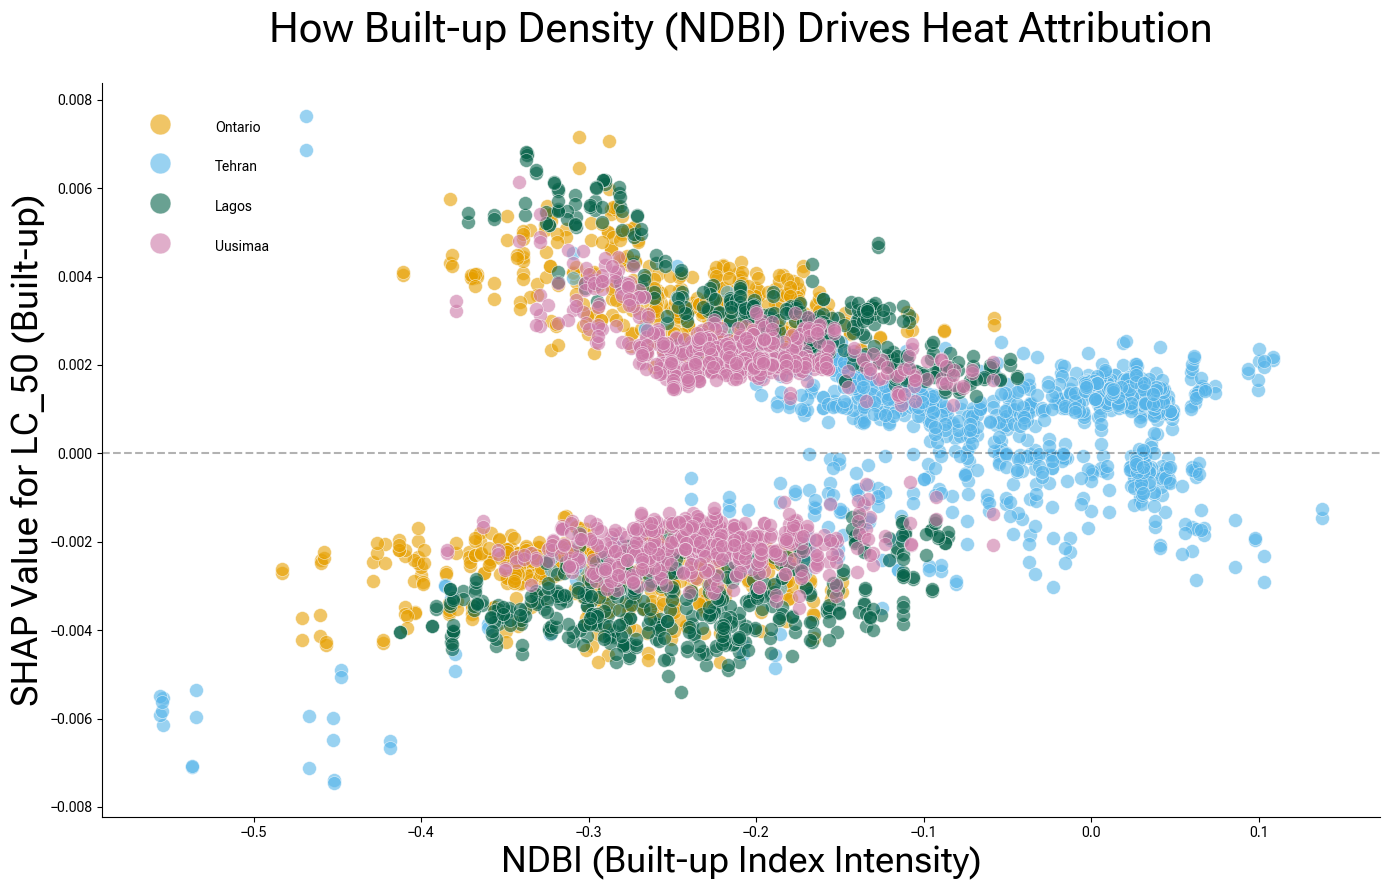

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data
# Get the column index for LC_50 and NDBI
lc50_idx = list(feature_cols_nogeo).index('LC_50')
ndbi_vals = X_test_nogeo['NDBI'].values

# Get SHAP values for LC_50 specifically
explainer = shap.TreeExplainer(xgb_estimator)
shap_values_test = explainer.shap_values(X_test_nogeo)
# If multi-target, ensures we have the right slice. 
# Usually shap_values is [n_samples, n_features] for single output
lc50_shap = shap_values_test[:, lc50_idx] 

# 2. City Mapping & Colors
cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]
# Using distinct, high-contrast colors for a poster
city_colors = {
    "Ontario": "#E69F00", # Orange
    "Tehran": "#56B4E9",  # Sky Blue
    "Lagos": "#066249",   # Bluish Green
    "Uusimaa": "#CC79A7"  # Reddish Purple
}

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(14, 9))

# Plot each city separately to create a clean categorical legend
for city in cities:
    mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
    ax.scatter(
        ndbi_vals[mask], 
        lc50_shap[mask], 
        label=city, 
        color=city_colors[city], 
        alpha=0.6, 
        edgecolors='w', 
        linewidth=0.5,
        s=100 # Larger points for poster visibility
    )

# --- Aesthetic Styling (Poster Scale) ---
ax.axhline(0, color='black', linestyle='--', alpha=0.3) # Baseline

# Spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Fonts & Labels
ax.set_title("How Built-up Density (NDBI) Drives Heat Attribution", 
             fontproperties=roboto_font, fontsize=30, pad=30)
ax.set_xlabel("NDBI (Built-up Index Intensity)", fontproperties=roboto_font, fontsize=26)
ax.set_ylabel("SHAP Value for LC_50 (Built-up)", fontproperties=roboto_font, fontsize=26)

# Ticks
ax.tick_params(axis='both', labelsize=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(roboto_font)

# Legend
leg = ax.legend(prop={'size': 22}, frameon=False, loc='upper left', markerscale=1.5)
for text in leg.get_texts():
    text.set_fontproperties(roboto_font)

plt.tight_layout()
plt.savefig("plots/shap/poster_ndbi_interaction.png", dpi=300, bbox_inches='tight')
plt.show()

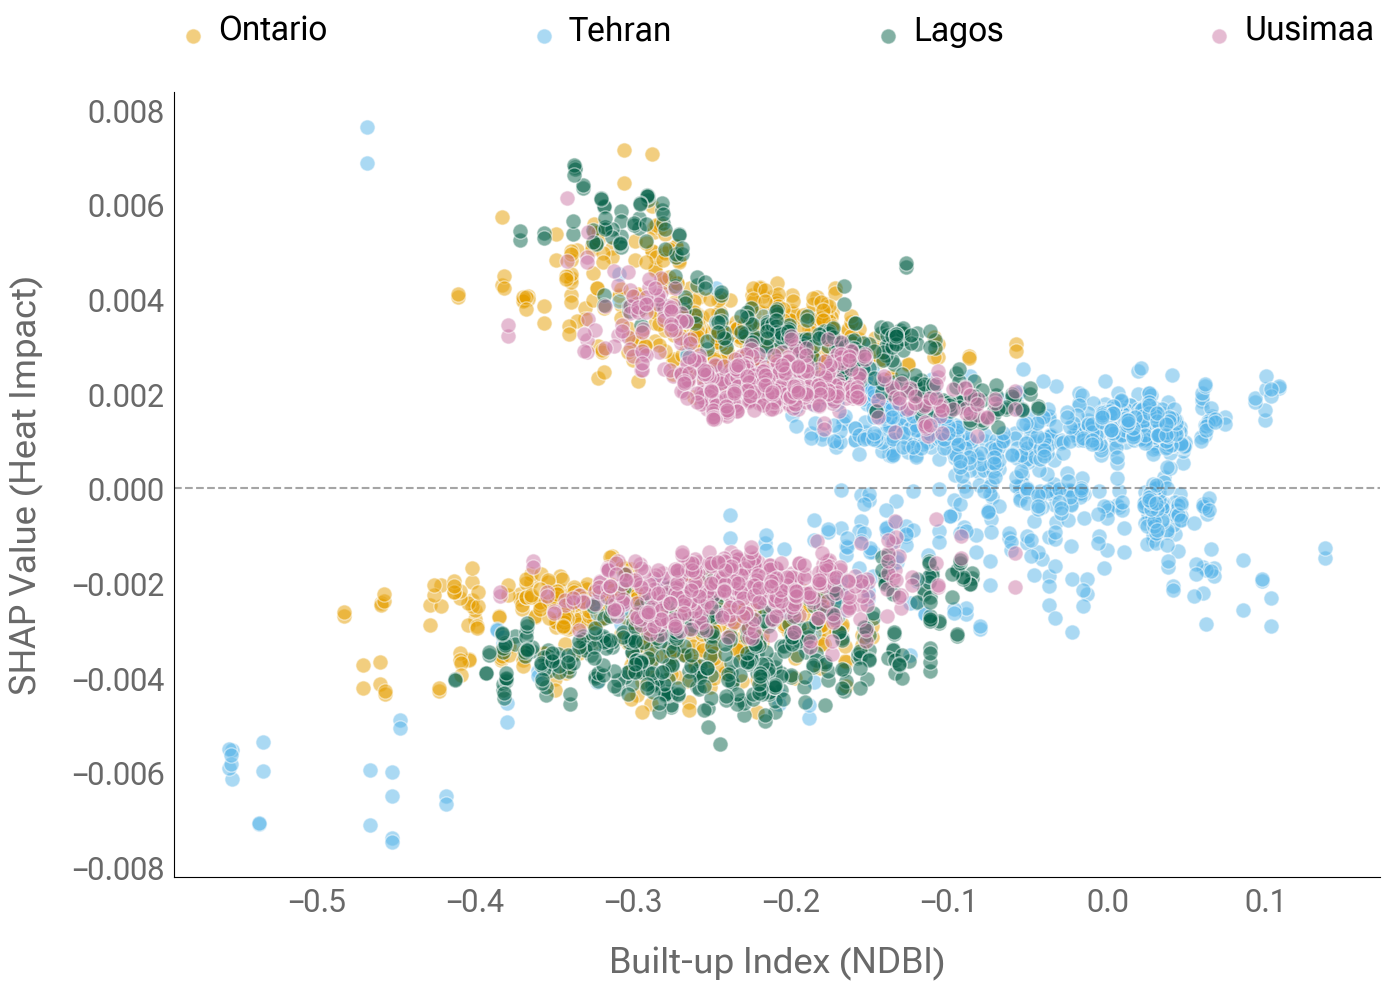

In [34]:
import matplotlib.pyplot as plt

# --- Poster-Ready Interaction Plot ---
fig, ax = plt.subplots(figsize=(14, 10))

# Plot each city
for city in cities:
    mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
    ax.scatter(
        ndbi_vals[mask], 
        lc50_shap[mask], 
        label=city, 
        color=city_colors[city], 
        alpha=0.5, 
        edgecolors='w', 
        s=120
    )

# Baseline
ax.axhline(0, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.6)

# --- Aesthetic Styling (Matching the Bar Chart) ---
# Remove Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove Ticks and Grid (Clean Look)
ax.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=True)
ax.grid(which = "minor")

# Labels (26pt to match poster body)
ax.set_xlabel("Built-up Index (NDBI)", fontproperties=roboto_font, fontsize=26, color="dimgray", labelpad=20)
ax.set_ylabel("SHAP Value (Heat Impact)", fontproperties=roboto_font, fontsize=26, color="dimgray", labelpad=20)

# Tick Labels
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontproperties(roboto_font)
    label.set_fontsize(22)
    label.set_color("dimgray")

# --- Legend at the Top (Matching the Bar Chart) ---
leg = ax.legend(bbox_to_anchor=(0., 1.05, 1., .102), loc='lower left',
                ncol=4, mode="expand", borderaxespad=0., frameon=False)

for text in leg.get_texts():
    text.set_fontproperties(roboto_font)
    text.set_fontsize(24)

plt.tight_layout()
plt.savefig("plots/shap/poster_interaction_clean.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [35]:
print(uhi_data["NDBI"].head())

0   -0.188529
1   -0.188529
2   -0.227187
3   -0.227187
4   -0.190666
Name: NDBI, dtype: float64


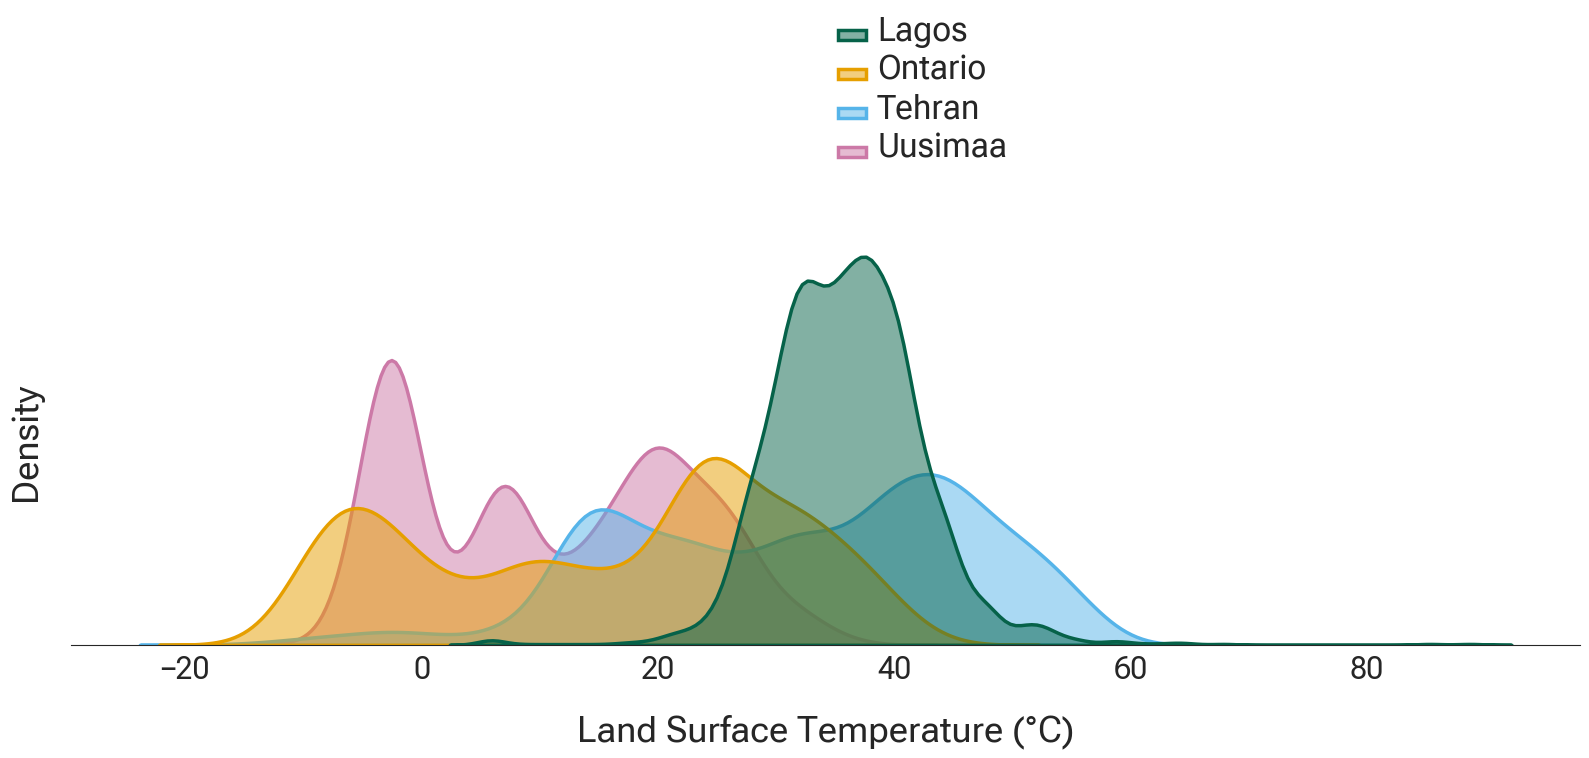

In [36]:
# 1. Unit Conversion
# Creating a copy to preserve original Kelvin values in uhi_data
plot_df = uhi_data.copy()
plot_df['LST_Celsius'] = plot_df['LST_day'] - 273.15

# 2. Figure Setup (Poster Scale)
plt.figure(figsize=(16, 8))
sns.set_style("white")

# 3. Distribution Plot
# city_colors mapping from the interaction plot logic
ax = sns.kdeplot(
    data=plot_df,
    x='LST_Celsius',
    hue='city',
    fill=True,
    palette=city_colors,
    alpha=0.5,
    linewidth=2.5,
    common_norm=False # Ensures each city's area is normalized independently
)

# 4. Poster Aesthetics
# Font sizes and labels match your 26pt baseline
plt.xlabel("Land Surface Temperature (°C)", fontproperties=roboto_font, fontsize=26, labelpad=20)
plt.ylabel("Density", fontproperties=roboto_font, fontsize=26, labelpad=20)

# Remove Chart Junk
sns.despine(left=True)
ax.set_yticks([]) # Density values are less important than the shape on a poster

# Tick Label Scaling
for label in ax.get_xticklabels():
    label.set_fontproperties(roboto_font)
    label.set_fontsize(22)

# Legend refinement
leg = ax.get_legend()
leg.set_title("") # Remove 'city' header
leg.set_bbox_to_anchor((0.5, 1.15))
leg.set_frame_on(False)
for text in leg.get_texts():
    text.set_fontproperties(roboto_font)
    text.set_fontsize(24)

plt.tight_layout()
plt.savefig("plots/lst_distribution_poster.png", dpi=300, transparent=True)
plt.show()

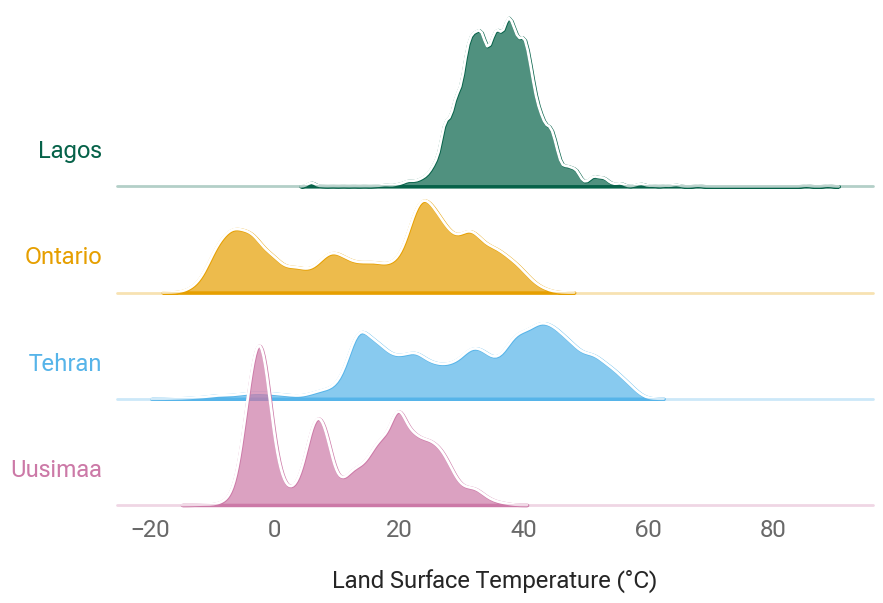

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Data (Celsius)
plot_df = uhi_data.copy()
plot_df['LST_C'] = plot_df['LST_day'] - 273.15

# 2. Set Theme for Stacking
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 3. Create FacetGrid (The 'Stack')
# hspace=-0.4 creates the overlap between the lines
g = sns.FacetGrid(plot_df, row="city", hue="city", aspect=6, height=1.5, palette=city_colors)

# 4. Draw the Density Lines
# Fill=True gives the 'stacked area' feel, while the line defines the distribution
g.map(sns.kdeplot, "LST_C", 
      bw_adjust=0.5, clip_on=False, 
      fill=True, alpha=0.7, linewidth=2.5)

# Add a white outline for separation
g.map(sns.kdeplot, "LST_C", clip_on=False, color="white", lw=2, bw_adjust=0.5)

# 5. Add Baselines
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False, alpha=0.3)

# 6. Manual Labels (Poster Scale)
def label_city(x, color, label):
    ax = plt.gca()
    ax.text(-0.02, 0.2, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes,
            fontproperties=roboto_font, fontsize=17)

g.map(label_city, "LST_C")

# 7. Final Aesthetic Styling
g.figure.subplots_adjust(hspace=-0.4) # Control the 'stacking' overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# X-axis Labeling
plt.xlabel("Land Surface Temperature (°C)", fontproperties=roboto_font, fontsize=17, labelpad=20)
for ax in g.axes.flat:
    for tick in ax.get_xticklabels():
        tick.set_fontproperties(roboto_font)
        tick.set_fontsize(17)
        tick.set_color("dimgray")

plt.savefig("plots/lst_ridgeline_poster.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()